# Project Choice 1: Multimodal Fake News Classification

**Group Members:**  
- Abdullah Naveed  
- Ahmed Jamil  

### Part 1: Data Exploration & Literature Review
In this part, we will explore the Fakeddit dataset by examining its structure, features, and distributions.  
We will also review relevant literature to understand prior approaches for multimodal fake news detection.  
This step will give us the foundation to design and implement effective text–image classification models in later stages.

In [1]:
import os
import io
import pandas as pd
import numpy as np
from urllib import request
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
from urllib import request
from PIL import Image

# Loading the Dataset

In [2]:
############################### Define dataset paths
BASE_DATA_DIR = Path("../..") / "project_dataset" / "fakeddit_data" / "multimodal_only_samples"

In [3]:
############################ Function to load dataset
def load_dataset(filename: str, sep="\t") -> pd.DataFrame:
    file_path = BASE_DATA_DIR / filename
    if not file_path.exists():
        raise FileNotFoundError(f"{file_path} not found. Please check dataset setup.")
    return pd.read_csv(file_path, sep=sep)

In [4]:
############################### Load train, validation, and test datasets
train_df = load_dataset("multimodal_train.tsv")
val_df   = load_dataset("multimodal_validate.tsv")
test_df  = load_dataset("multimodal_test_public.tsv")

# Some basic info/stats about datasets

In [5]:
############################### Print dataset stats
print("Train dataset shape:", train_df.shape)
print("Validation dataset shape:", val_df.shape)
print("Test dataset shape:", test_df.shape)

print("\nColumn names in train dataset:")
print(train_df.columns.tolist())

print("\nData types in train dataset:")
print(train_df.dtypes)

Train dataset shape: (564000, 16)
Validation dataset shape: (59342, 16)
Test dataset shape: (59319, 16)

Column names in train dataset:
['author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id', 'image_url', 'linked_submission_id', 'num_comments', 'score', 'subreddit', 'title', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label']

Data types in train dataset:
author                   object
clean_title              object
created_utc             float64
domain                   object
hasImage                   bool
id                       object
image_url                object
linked_submission_id     object
num_comments            float64
score                     int64
subreddit                object
title                    object
upvote_ratio            float64
2_way_label               int64
3_way_label               int64
6_way_label               int64
dtype: object


In [6]:
############################### Preview first 10 rows of train dataset
print("\nFirst 5 rows of train dataset:")
train_df.head(5)


First 5 rows of train dataset:


,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,mildlyinteresting,My Walgreens offbrand Mucinex was engraved wit...,0.84,1,0,0
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,pareidolia,This concerned sink with a tiny hat,0.99,0,2,2
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,neutralnews,Hackers leak emails from UAE ambassador to US,0.92,1,0,0
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,photoshopbattles,PsBattle: Puppy taking in the view,0.95,1,0,0
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,pareidolia,I found a face in my sheet music too!,0.84,0,2,2


# Missingness & modality presence

In [7]:
############################### Missingness (counts + normalized) across splits
def plot_missingness_multi(df_dict, cols=None, treat_empty=True, top_n=12, title="Missing values per column"):
    ############################### union of columns if not provided
    if cols is None:
        all_cols = set()
        for df in df_dict.values():
            all_cols |= set(df.columns.tolist())
        cols = sorted(all_cols)

    ############################### build counts table
    counts = pd.DataFrame(index=cols, columns=df_dict.keys(), dtype=float)
    totals = {name: len(df) for name, df in df_dict.items()}

    for split_name, df in df_dict.items():
        nan_counts = df[cols].isna().sum()
        counts[split_name] = nan_counts.values

        if treat_empty:
            empties = {}
            for c in cols:
                if c in df.columns and df[c].dtype == object:
                    empties[c] = (df[c].astype(str).str.strip()=="").sum()
                else:
                    empties[c] = 0
            counts[split_name] = counts[split_name].astype(float) + pd.Series(empties)

    ############################### pick top-N by total missing
    counts["_total"] = counts.sum(axis=1)
    counts = counts.sort_values("_total", ascending=False).head(top_n).drop(columns="_total")

    ############################### print counts
    print("\n=== Missing Counts (NaN + empty strings) ===")
    print(counts)

    ############################### absolute counts bar
    ax = counts.plot(kind="bar", figsize=(min(16, 1.2*len(counts.index)+6), 6))
    ax.set_title(title + " (Counts)")
    ax.set_xlabel("Columns")
    ax.set_ylabel("Count of missing")
    ax.legend(title="Split")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    ############################### normalized (percent of rows)
    normed = counts.copy()
    for split_name in df_dict.keys():
        normed[split_name] = normed[split_name] / totals[split_name] * 100

    print("\n=== Missing Percentages (relative to dataset size) ===")
    print(normed.round(2))

    ax = normed.plot(kind="bar", figsize=(min(16, 1.2*len(normed.index)+6), 6))
    ax.set_title(title + " (Percent of rows)")
    ax.set_xlabel("Columns")
    ax.set_ylabel("Missing (%)")
    ax.legend(title="Split")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return counts, normed


=== Missing Counts (NaN + empty strings) ===
                         Train
linked_submission_id  396143.0
domain                167857.0
num_comments          167857.0
upvote_ratio          167857.0
author                 28710.0
image_url               1534.0
2_way_label                0.0
3_way_label                0.0
6_way_label                0.0
clean_title                0.0
created_utc                0.0
hasImage                   0.0


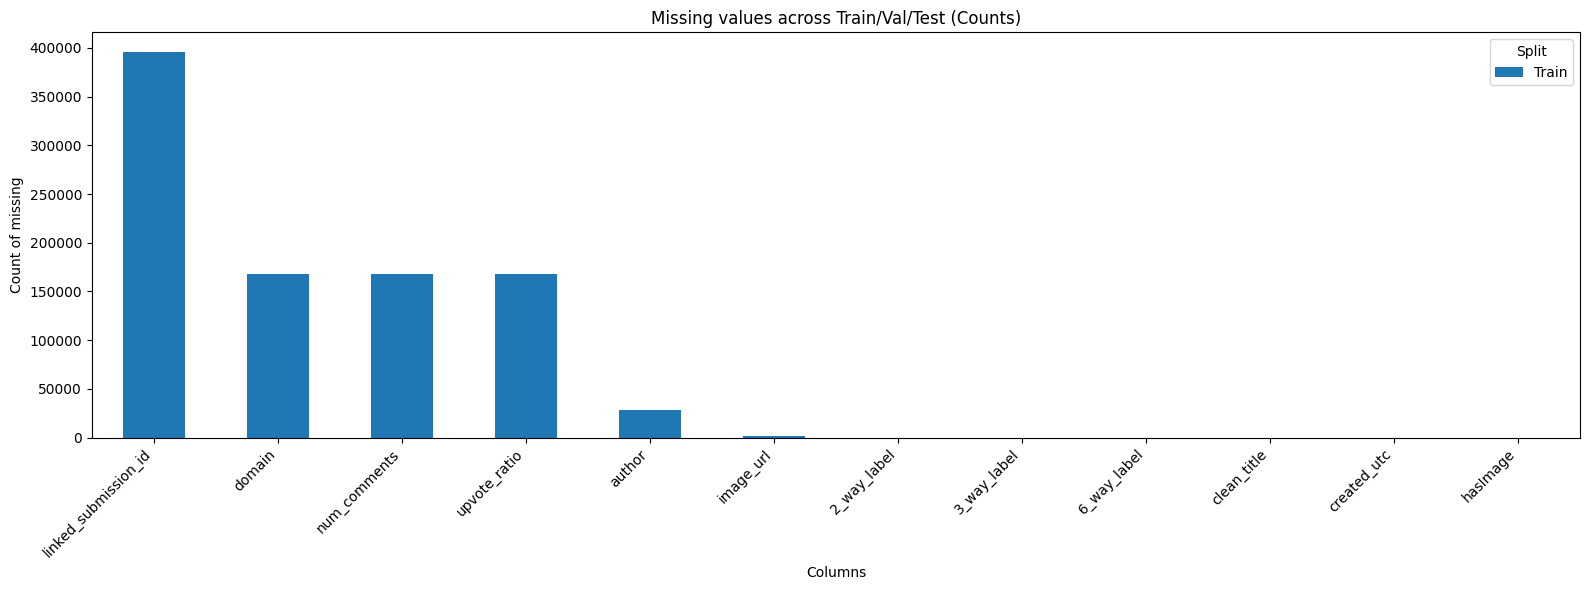


=== Missing Percentages (relative to dataset size) ===
                      Train
linked_submission_id  70.24
domain                29.76
num_comments          29.76
upvote_ratio          29.76
author                 5.09
image_url              0.27
2_way_label            0.00
3_way_label            0.00
6_way_label            0.00
clean_title            0.00
created_utc            0.00
hasImage               0.00


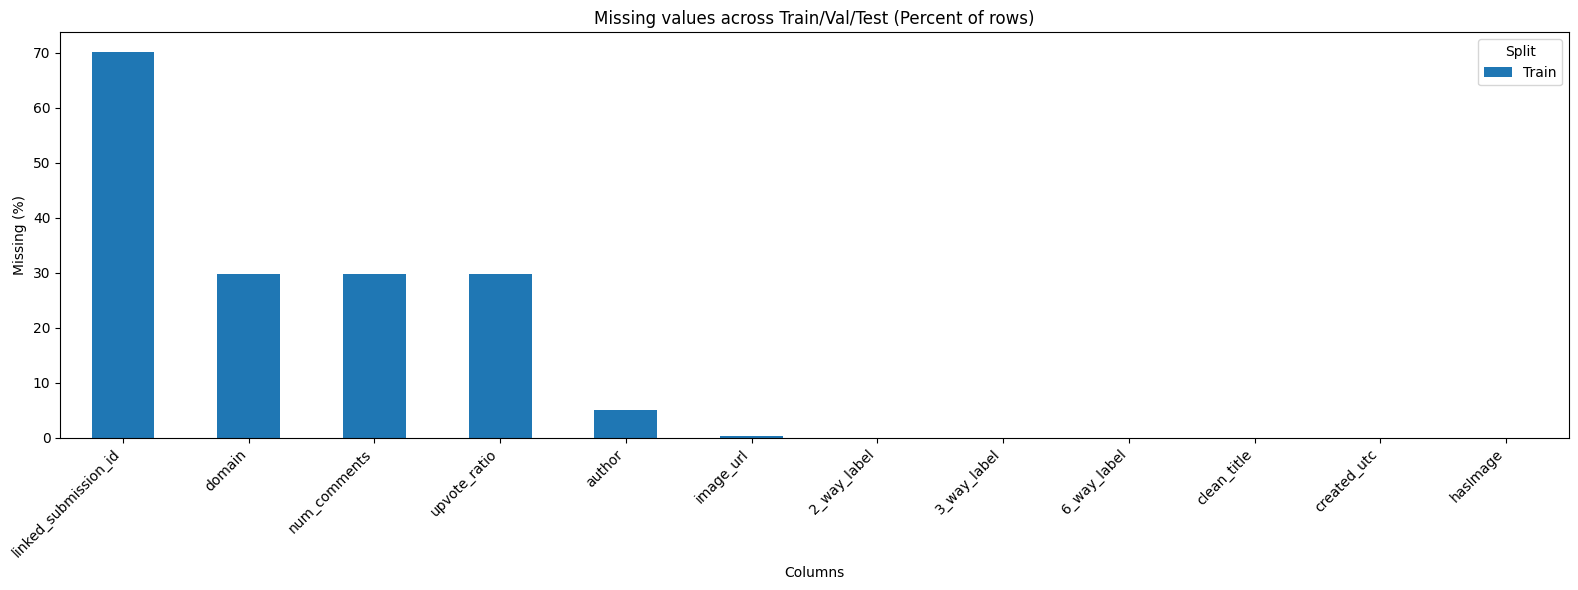

In [8]:
counts, normed = plot_missingness_multi(
    {"Train": train_df},
    treat_empty=True,
    top_n=12,
    title="Missing values across Train/Val/Test"
)

# Label distribution & imbalance across splits

In [19]:
############################### Class balance across splits (Counts + %)
def plot_class_balance_multi(df_dict, label_col="2_way_label", title_prefix=None):
    if title_prefix is None:
        title_prefix = label_col

    ############################### build counts table
    counts = {name: df[label_col].value_counts(dropna=False).sort_index()
              for name, df in df_dict.items()}
    counts_df = pd.DataFrame(counts).fillna(0).astype(int)

    ############################### print tables
    print(f"\n=== {label_col} — Counts ===")
    print(counts_df)

    pct_df = counts_df.div(counts_df.sum(axis=0), axis=1) * 100
    print(f"\n=== {label_col} — Percentages ===")
    print(pct_df.round(2))

    ############################### plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    # absolute counts
    counts_df.plot(kind="bar", ax=axes[0])
    axes[0].set_title(f"{title_prefix} — Counts")
    axes[0].set_xlabel("Class label")
    axes[0].set_ylabel("Count")
    axes[0].grid(axis="y", alpha=0.25)

    # percentages
    pct_df.plot(kind="bar", ax=axes[1])
    axes[1].set_title(f"{title_prefix} — Percentages")
    axes[1].set_xlabel("Class label")
    axes[1].set_ylabel("Percentage (%)")
    axes[1].grid(axis="y", alpha=0.25)

    plt.show()
    return counts_df, pct_df


=== 2_way_label — Counts ===
              Train    Val   Test
2_way_label                      
0            341919  36022  35812
1            222081  23320  23507

=== 2_way_label — Percentages ===
             Train   Val   Test
2_way_label                    
0            60.62  60.7  60.37
1            39.38  39.3  39.63


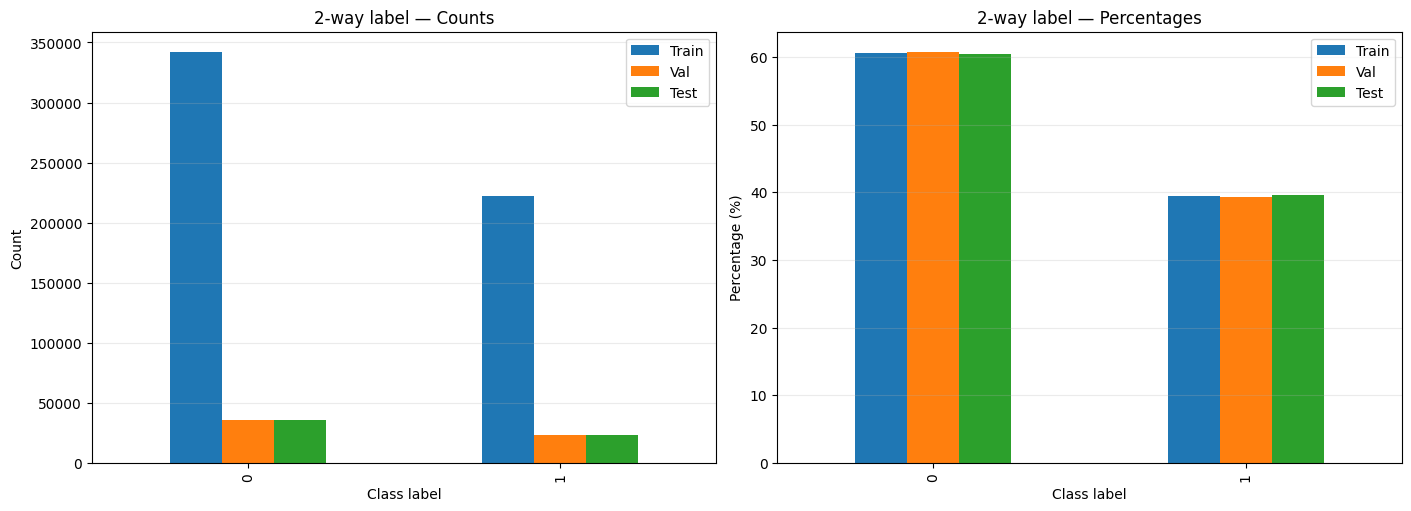


=== 3_way_label — Counts ===
              Train    Val   Test
3_way_label                      
0            222081  23320  23507
1             13848   1365   1492
2            328071  34657  34320

=== 3_way_label — Percentages ===
             Train   Val   Test
3_way_label                    
0            39.38  39.3  39.63
1             2.46   2.3   2.52
2            58.17  58.4  57.86


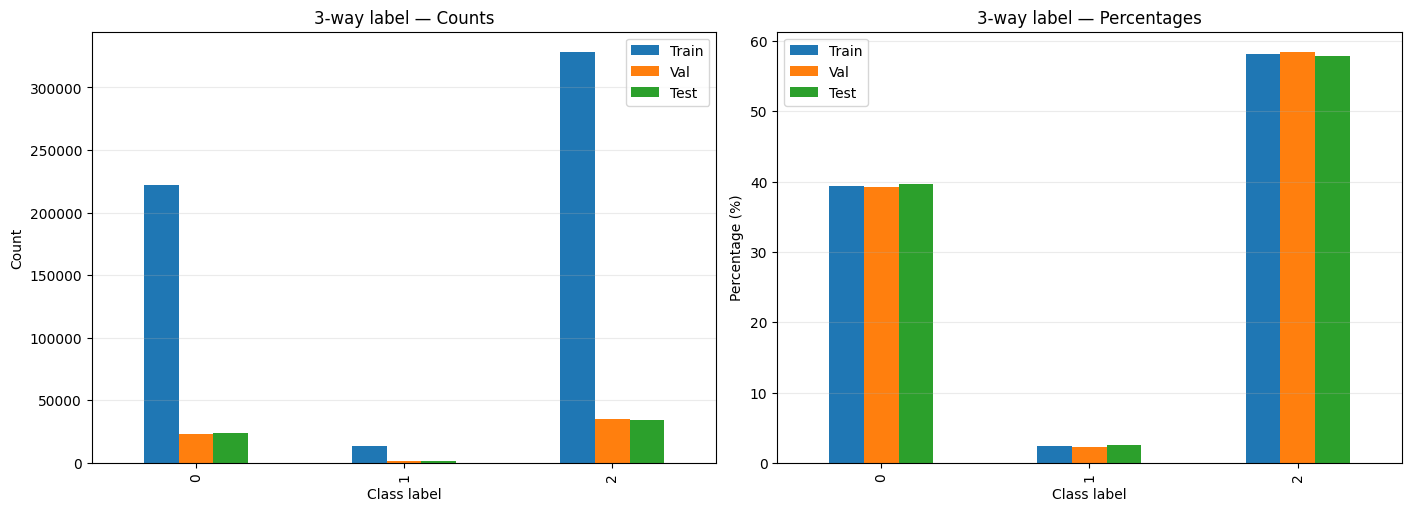


=== 6_way_label — Counts ===
              Train    Val   Test
6_way_label                      
0            222081  23320  23507
1             33481   3521   3514
2            107221  11277  11297
3             11784   1238   1224
4            167857  17810  17472
5             21576   2176   2305

=== 6_way_label — Percentages ===
             Train    Val   Test
6_way_label                     
0            39.38  39.30  39.63
1             5.94   5.93   5.92
2            19.01  19.00  19.04
3             2.09   2.09   2.06
4            29.76  30.01  29.45
5             3.83   3.67   3.89


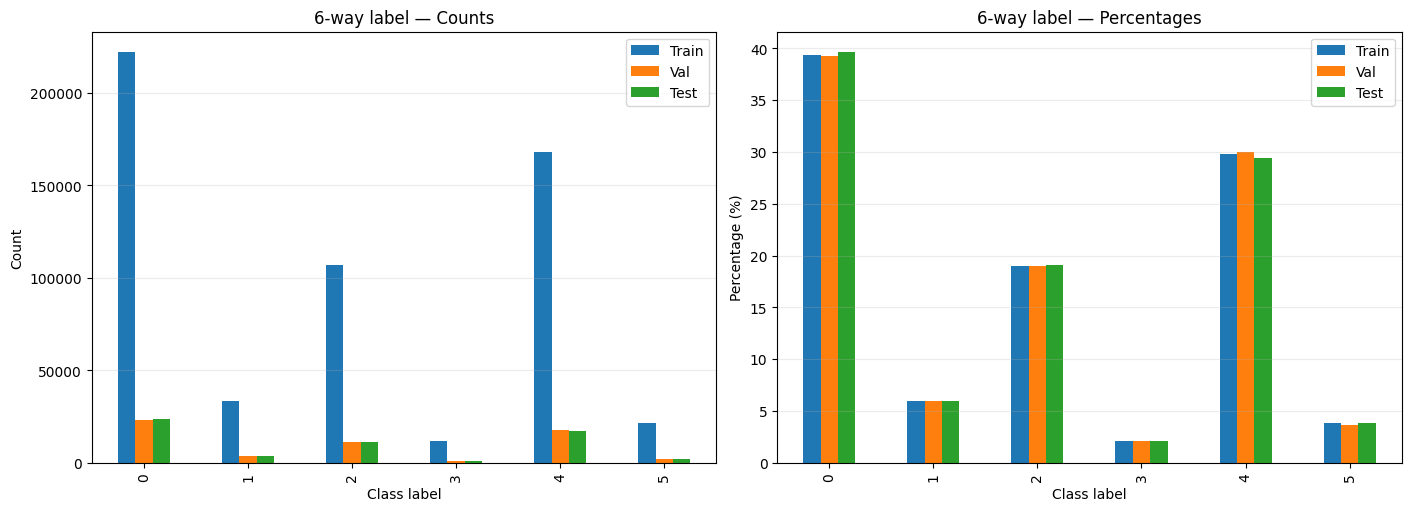

In [20]:
############################### Run on your splits for each target
split_dict = {"Train": train_df, "Val": val_df, "Test": test_df}

_2_counts, _2_pct = plot_class_balance_multi(split_dict, label_col="2_way_label", title_prefix="2-way label")
_3_counts, _3_pct = plot_class_balance_multi(split_dict, label_col="3_way_label", title_prefix="3-way label")
_6_counts, _6_pct = plot_class_balance_multi(split_dict, label_col="6_way_label", title_prefix="6-way label")

# Text Features characteristics analysis

### Title Length Analysis

In [29]:
def plot_title_length_vs_labels_train(train_df,text_col="title",label_cols=("2_way_label","3_way_label","6_way_label"),clip_quantile=0.99,bins=50,use_violin=True):
    ############################### Pre-compute lengths once
    df = train_df.copy()
    df["_len"] = df[text_col].fillna("").astype(str).str.len()

    ############################### Loop over each label column
    for label_col in label_cols:
        if label_col not in df.columns:
            continue

        ############################### Create a plotting copy with clipped lengths
        q = df["_len"].quantile(clip_quantile)
        plot_df = df[[label_col, "_len"]].dropna().copy()
        plot_df["_len_clip"] = np.minimum(plot_df["_len"], q)

        ############################### Print a small, useful summary table
        summary = plot_df.groupby(label_col)["_len"].agg(
            n="count", mean="mean", std="std", p50="median",
            p90=lambda s: s.quantile(0.90)
        ).round(2)
        print(f"\n=== {text_col} length vs {label_col} (TRAIN) ===")
        print(summary)

        ############################### Make two simple plots (side-by-side)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

        
        # ---- LEFT: violin/box plot (shows median + spread clearly)
        groups = [g["_len_clip"].values for _, g in plot_df.groupby(label_col)]
        labels = [str(k) for k in plot_df[label_col].unique()]

        if use_violin:
            axes[0].violinplot(groups, showmeans=True, showmedians=True, showextrema=True)
            axes[0].set_title(f"{text_col} length by {label_col} (violin, clipped @{int(clip_quantile*100)}%)")
        else:
            axes[0].boxplot(groups, showmeans=True)
            axes[0].set_title(f"{text_col} length by {label_col} (box, clipped @{int(clip_quantile*100)}%)")

        axes[0].set_xticks(range(1, len(labels)+1))
        axes[0].set_xticklabels(labels)
        axes[0].set_ylabel("characters (clipped)")

        # ---- RIGHT: normalized histograms (density=1 per label → shape comparison)
        for lab, g in plot_df.groupby(label_col):
            axes[1].hist(g["_len_clip"], bins=bins, density=True, alpha=0.4, label=f"{label_col}={lab}")
        axes[1].set_title(f"{text_col} length density by {label_col}")
        axes[1].set_xlabel("characters (clipped)")
        axes[1].set_ylabel("density")
        axes[1].legend(title="Label")

        plt.show()

    ############################### Cleanup
    df.drop(columns=["_len"], inplace=True, errors="ignore")


=== title length vs 2_way_label (TRAIN) ===
                  n   mean    std   p50   p90
2_way_label                                  
0            341919  38.95  35.82  28.0  83.0
1            222081  57.42  31.99  52.0  90.0


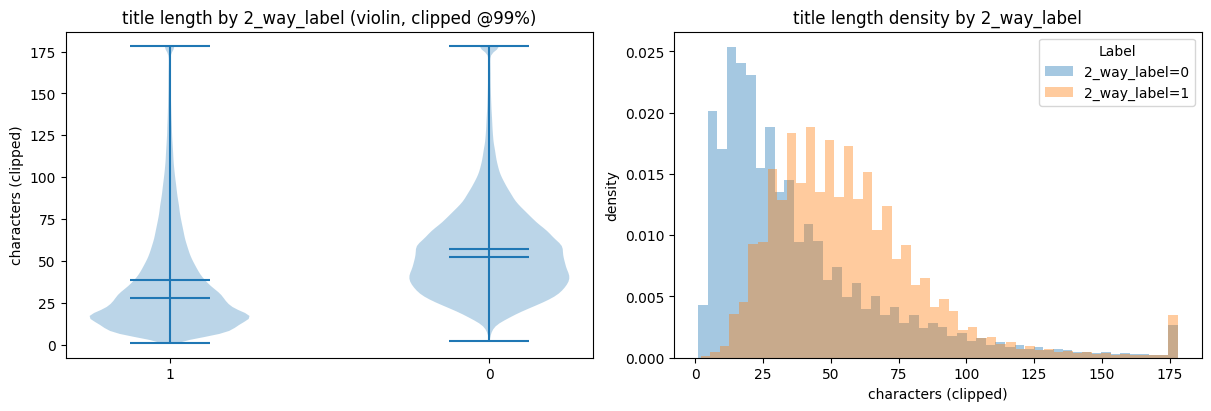


=== title length vs 3_way_label (TRAIN) ===
                  n   mean    std   p50    p90
3_way_label                                   
0            222081  57.42  31.99  52.0   90.0
1             13848  79.65  45.62  69.0  138.3
2            328071  37.23  34.30  27.0   79.0


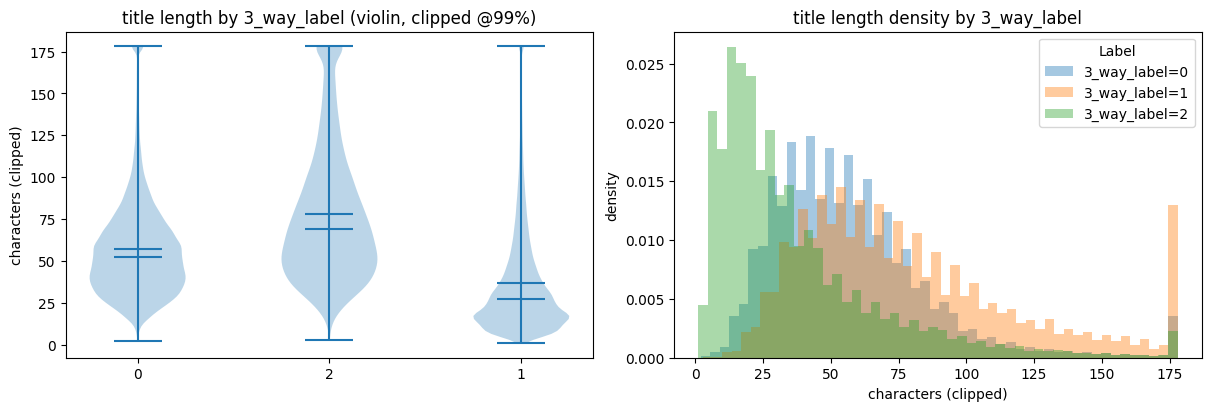


=== title length vs 6_way_label (TRAIN) ===
                  n   mean    std   p50    p90
6_way_label                                   
0            222081  57.42  31.99  52.0   90.0
1             33481  48.07  32.14  37.0   92.0
2            107221  45.44  30.27  39.0   84.0
3             11784  80.37  36.96  75.0  127.0
4            167857  22.33  20.36  17.0   42.0
5             21576  99.27  56.03  87.0  177.0


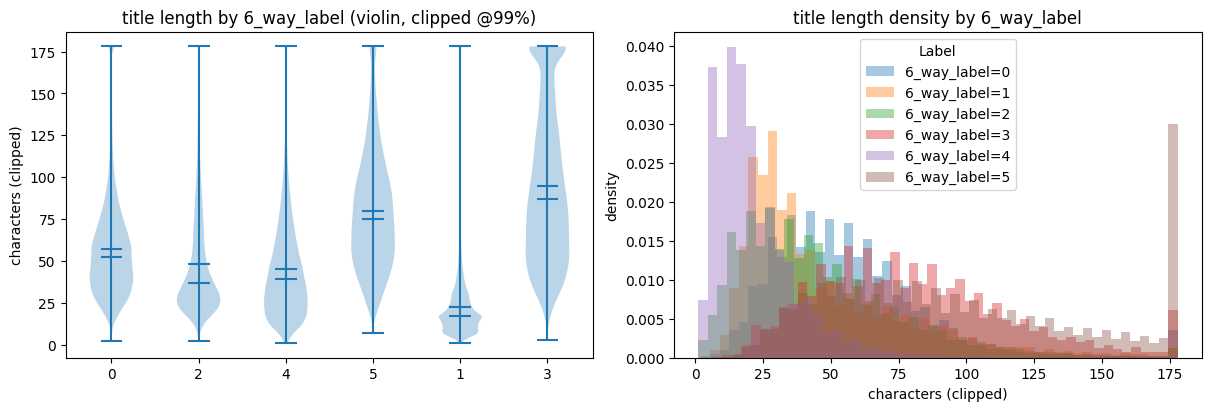

In [30]:
############################### Run: title length vs labels on TRAIN
plot_title_length_vs_labels_train(
    train_df,
    text_col="title",
    label_cols=("2_way_label","3_way_label","6_way_label"),
    clip_quantile=0.99,
    bins=50,
    use_violin=True
)

### Author column analysis

=== Author column analysis ===
Unique authors: 238,619
Missing authors: 28,710

Top authors (by number of posts):
author
ApiContraption       14350
all-top-today_SS      3805
dwaxe                 2611
PSBBot                1965
Sariel007             1690
TheBlazingPhoenix     1155
DrWankalot             997
artunitinc             991
DaminDrexil            970
flappytowel            926
Name: count, dtype: int64


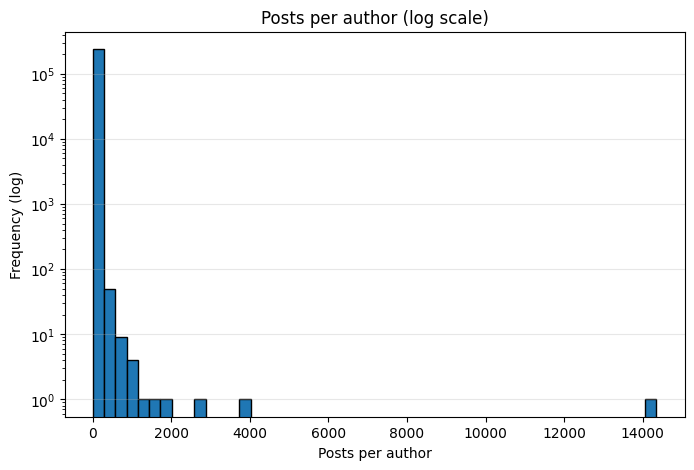

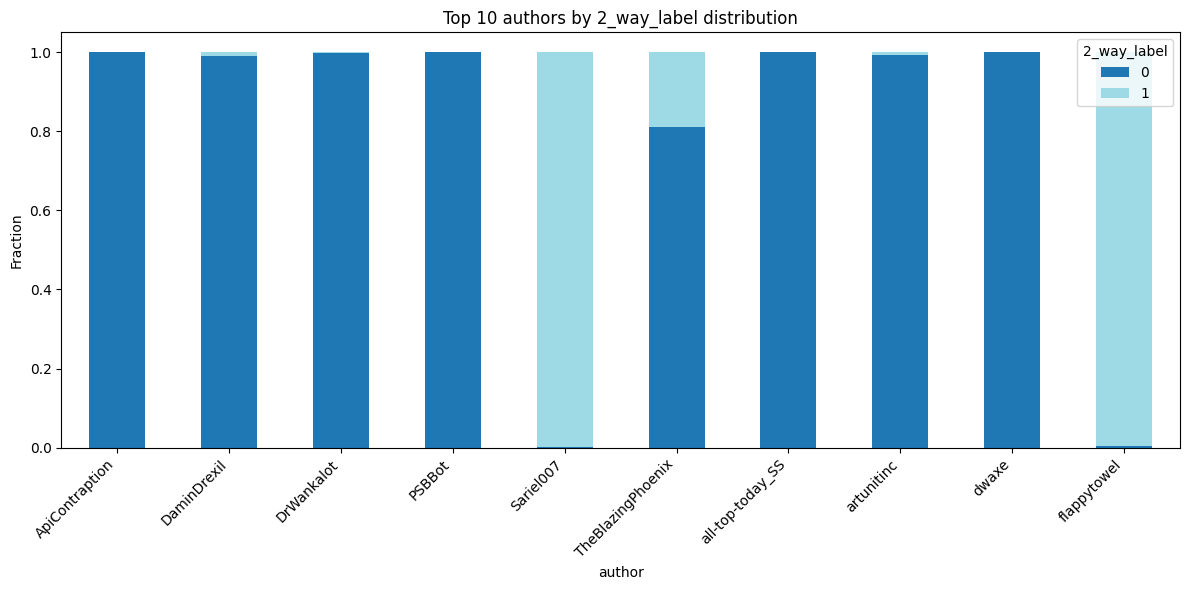

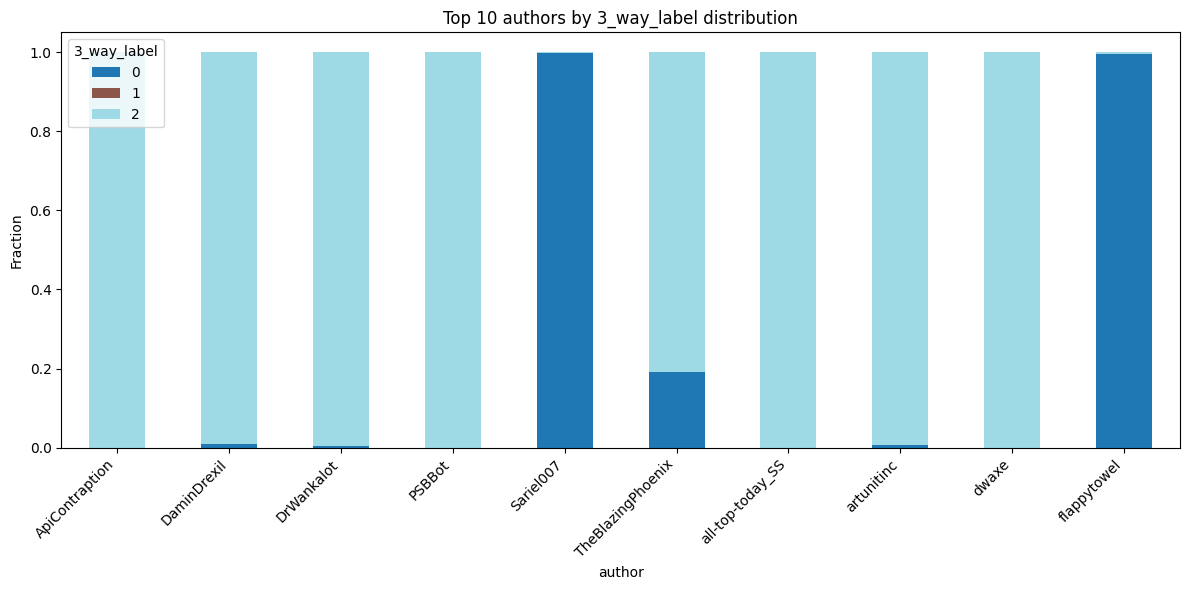

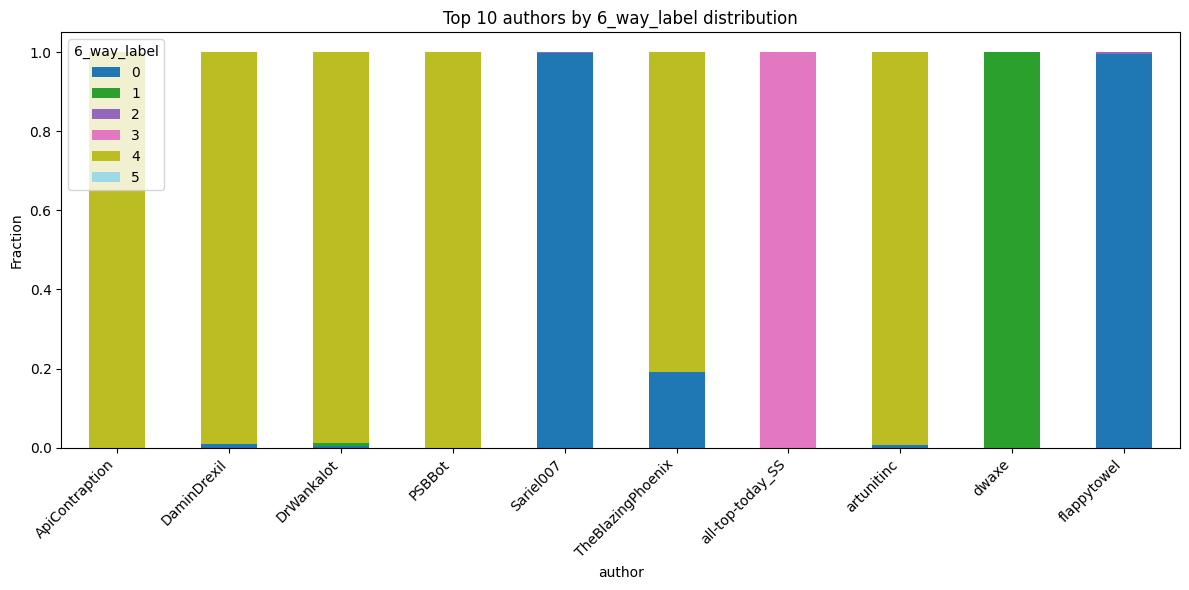

In [28]:
############################### Author column analysis
def analyze_author_column(df, label_col="2_way_label", top_n=15):
    if "author" not in df.columns:
        print("No 'author' column found.")
        return

    counts = df["author"].value_counts(dropna=True)
    if label_col == "2_way_label":
        print("=== Author column analysis ===")
        n_unique = df["author"].nunique(dropna=True)
        n_missing = df["author"].isna().sum()
        print(f"Unique authors: {n_unique:,}")
        print(f"Missing authors: {n_missing:,}")
        
        # frequency of posts per author
        print("\nTop authors (by number of posts):")
        print(counts.head(top_n))
        ############################### Distribution of posts per author
        plt.figure(figsize=(8,5))
        plt.hist(counts.values, bins=50, log=True, edgecolor="black")
        plt.title("Posts per author (log scale)")
        plt.xlabel("Posts per author")
        plt.ylabel("Frequency (log)")
        plt.grid(axis="y", alpha=0.3)
        plt.show()

    ############################### Top authors by label
    top_authors = counts.head(top_n).index
    df_top = df[df["author"].isin(top_authors)]
    ctab = pd.crosstab(df_top["author"], df_top[label_col])
    ctab_norm = ctab.div(ctab.sum(axis=1), axis=0)

    ax = ctab_norm.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab20")
    ax.set_title(f"Top {top_n} authors by {label_col} distribution")
    ax.set_ylabel("Fraction")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

############################### Run on TRAIN
analyze_author_column(train_df, label_col="2_way_label", top_n=10)
analyze_author_column(train_df, label_col="3_way_label", top_n=10)
analyze_author_column(train_df, label_col="6_way_label", top_n=10)

### Clean title analysis by label

In [34]:
############################### Clean title analysis by label (fixed)
import re
from collections import Counter

def analyze_clean_title_by_label(df, text_col="clean_title",
                                 label_cols=("2_way_label","3_way_label","6_way_label"),
                                 top_n=15, clip_q=0.99, sample_n=100_000):
    if text_col not in df.columns:
        print(f"No '{text_col}' column found.")
        return
    
    work = df.copy()
    work["_len_chars"] = work[text_col].fillna("").astype(str).str.len()
    work["_len_words"] = work[text_col].fillna("").astype(str).str.split().map(len)

    for label_col in label_cols:
        if label_col not in work.columns:
            continue

        print(f"\n=== {text_col} analysis by {label_col} ===")

        ############################### summary stats per class (fixed keys)
        summary = work.groupby(label_col)[["_len_chars","_len_words"]].agg(
            n_chars_mean=("._len_chars","mean") if False else ("_len_chars","mean"),
            n_chars_med =("_len_chars","median"),
            n_words_mean=("_len_words","mean"),
            n_words_med =("_len_words","median"),
            n          =("_len_chars","count")
        ).round(2)
        print(summary)

        ############################### clip for plotting
        plot_df = work[[label_col,"_len_chars","_len_words"]].copy()
        for c in ["_len_chars","_len_words"]:
            q = plot_df[c].quantile(clip_q)
            plot_df[c] = np.minimum(plot_df[c], q)

        # violin plots
        fig, axes = plt.subplots(1,2,figsize=(12,5))
        groups_chars = [g["_len_chars"].values for _,g in plot_df.groupby(label_col)]
        xlabs = [str(x) for x in sorted(plot_df[label_col].unique())]
        axes[0].violinplot(groups_chars, showmeans=True, showmedians=True)
        axes[0].set_title(f"Char length by {label_col}")
        axes[0].set_xticks(range(1, len(xlabs)+1)); axes[0].set_xticklabels(xlabs)
        axes[0].set_ylabel("chars")

        groups_words = [g["_len_words"].values for _,g in plot_df.groupby(label_col)]
        axes[1].violinplot(groups_words, showmeans=True, showmedians=True)
        axes[1].set_title(f"Word length by {label_col}")
        axes[1].set_xticks(range(1, len(xlabs)+1)); axes[1].set_xticklabels(xlabs)
        axes[1].set_ylabel("words")
        plt.tight_layout(); plt.show()

        # density histograms
        for c, lbl in [("_len_chars","chars"),("_len_words","words")]:
            plt.figure(figsize=(10,5))
            for lab, g in plot_df.groupby(label_col):
                plt.hist(g[c], bins=40, density=True, alpha=0.5, label=f"{label_col}={lab}")
            plt.title(f"{text_col} {lbl} distribution by {label_col} (clipped @{int(clip_q*100)}%)")
            plt.xlabel(lbl); plt.ylabel("density"); plt.legend(title="Class"); plt.grid(axis="y", alpha=0.3)
            plt.tight_layout(); plt.show()

        ############################### top tokens per class
        use = work[[text_col,label_col]].dropna().copy()
        if sample_n and len(use) > sample_n:
            use = use.sample(sample_n, random_state=7)

        print(f"\nTop {top_n} tokens in {text_col} by {label_col}:")
        for lab, sub in use.groupby(label_col):
            toks = [w.lower() for s in sub[text_col].astype(str)
                    for w in re.findall(r"\b\w+\b", s)]
            top = Counter(toks).most_common(top_n)
            print(f"\nClass {lab}:")
            for w,c in top:
                print(f"  {w:15s} {c}")

            if top:
                words, freqs = zip(*top)
                plt.figure(figsize=(10,5))
                plt.bar(words, freqs, edgecolor="black")
                plt.title(f"Top {top_n} tokens in {text_col} (class={lab})")
                plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

    ############################### cleanup
    work.drop(columns=["_len_chars","_len_words"], inplace=True, errors="ignore")


=== clean_title analysis by 2_way_label ===
             n_chars_mean  n_chars_med  n_words_mean  n_words_med       n
2_way_label                                                              
0                   34.36         26.0          6.16          5.0  341919
1                   53.57         49.0          9.45          9.0  222081


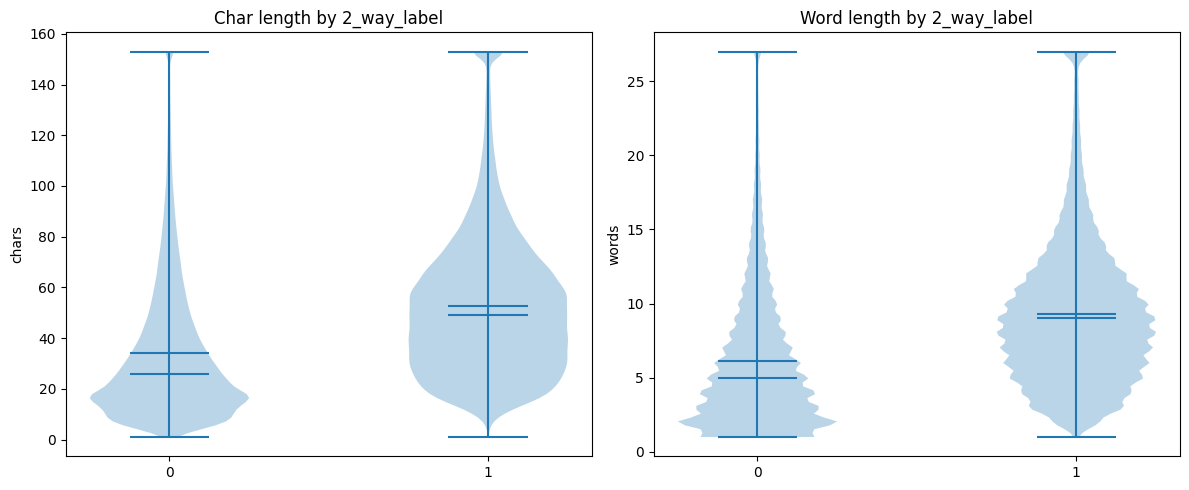

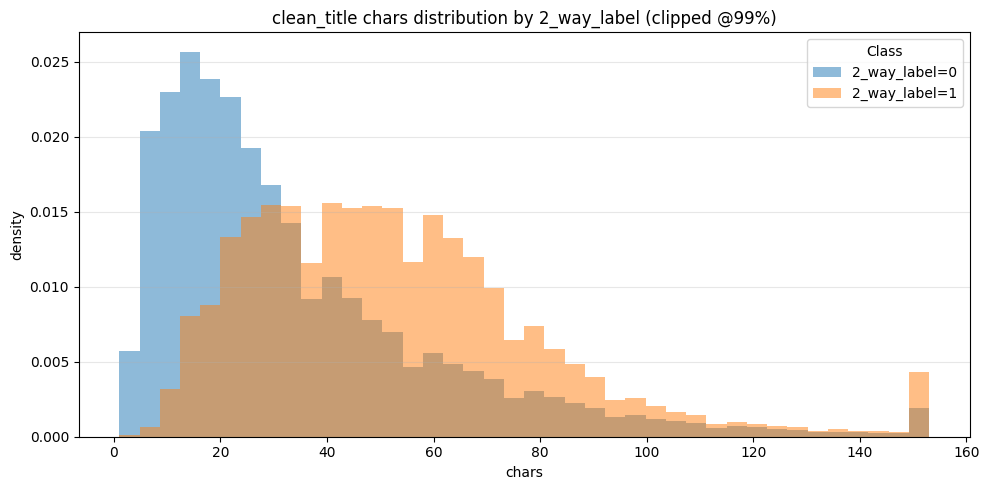

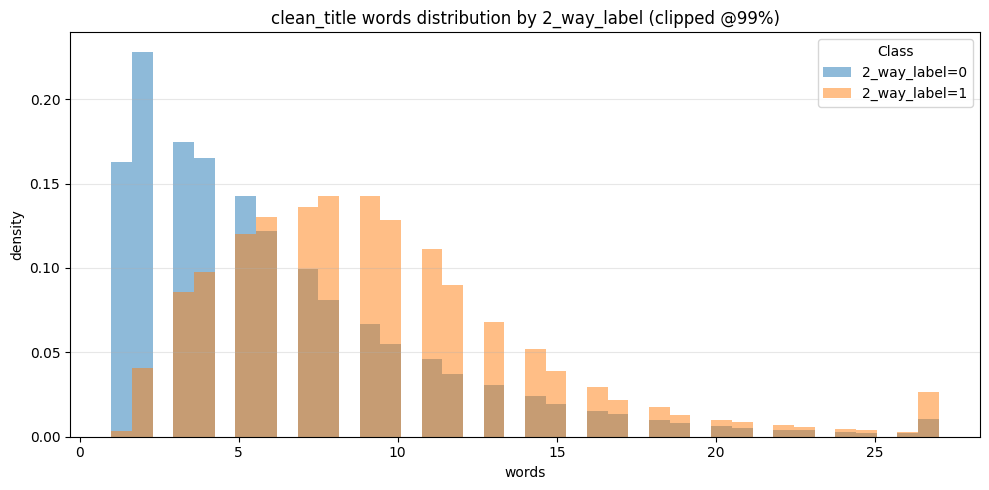


Top 15 tokens in clean_title by 2_way_label:

Class 0:
  the             16621
  a               9433
  of              7987
  to              6812
  in              5473
  this            4722
  i               4197
  is              3463
  and             3392
  my              3184
  on              3019
  you             2986
  for             2832
  it              2217
  with            2077


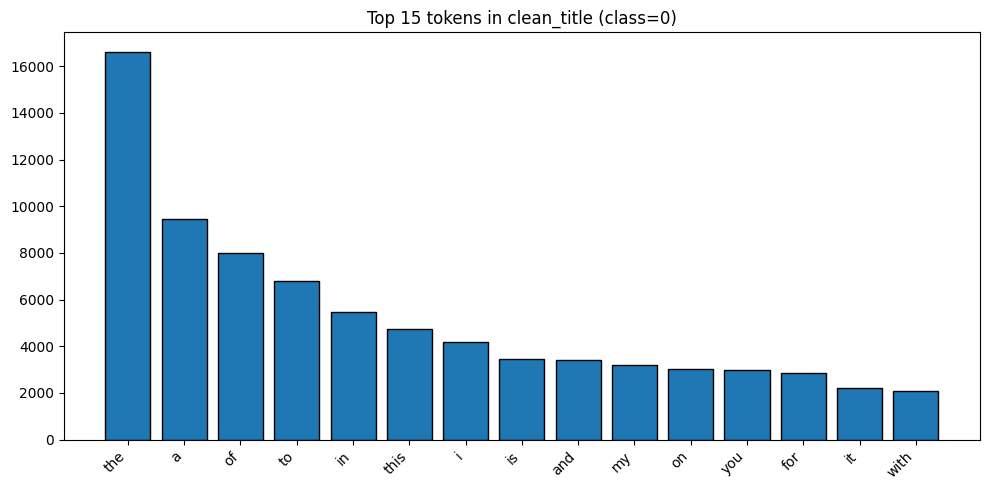


Class 1:
  a               12740
  the             12345
  in              8992
  this            8481
  of              7217
  to              7194
  on              4810
  my              4807
  and             3707
  for             3623
  with            3329
  at              2738
  i               2481
  is              2417
  from            2186


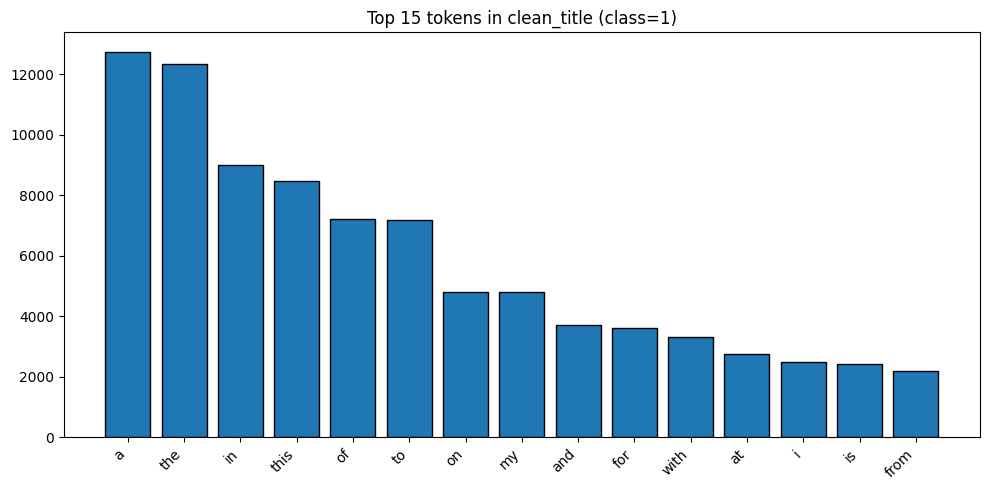


=== clean_title analysis by 3_way_label ===
             n_chars_mean  n_chars_med  n_words_mean  n_words_med       n
3_way_label                                                              
0                   53.57         49.0          9.45          9.0  222081
1                   67.79         57.0         11.21          9.0   13848
2                   32.95         25.0          5.95          5.0  328071


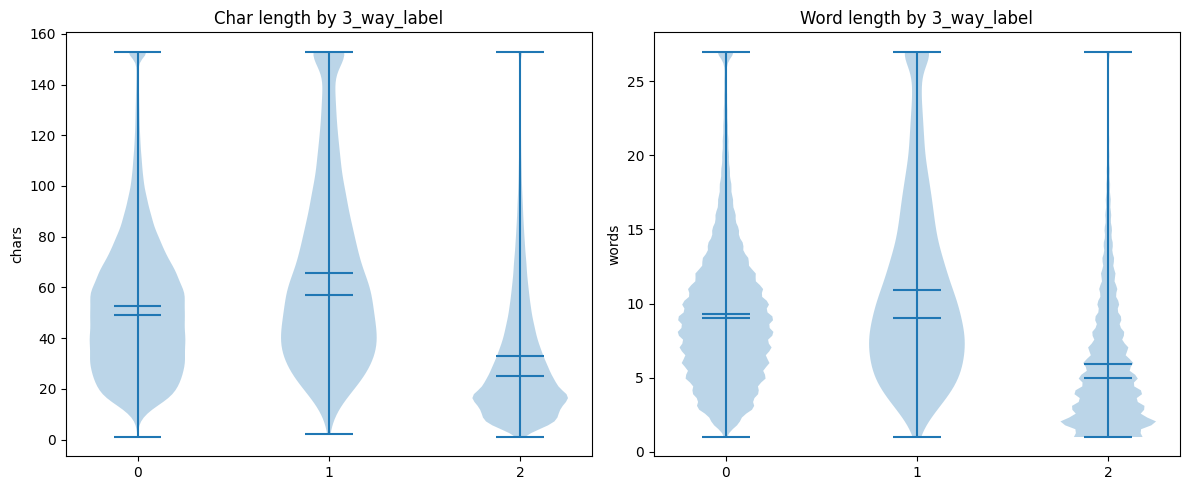

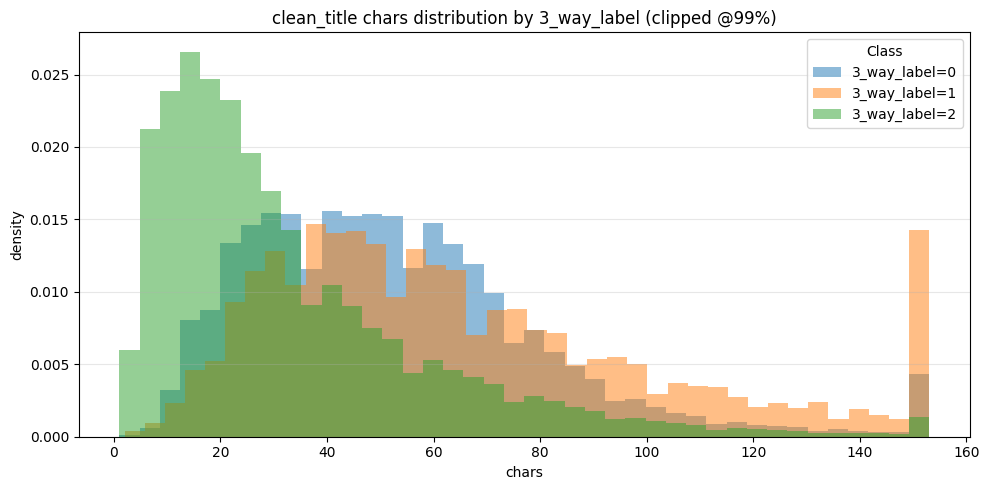

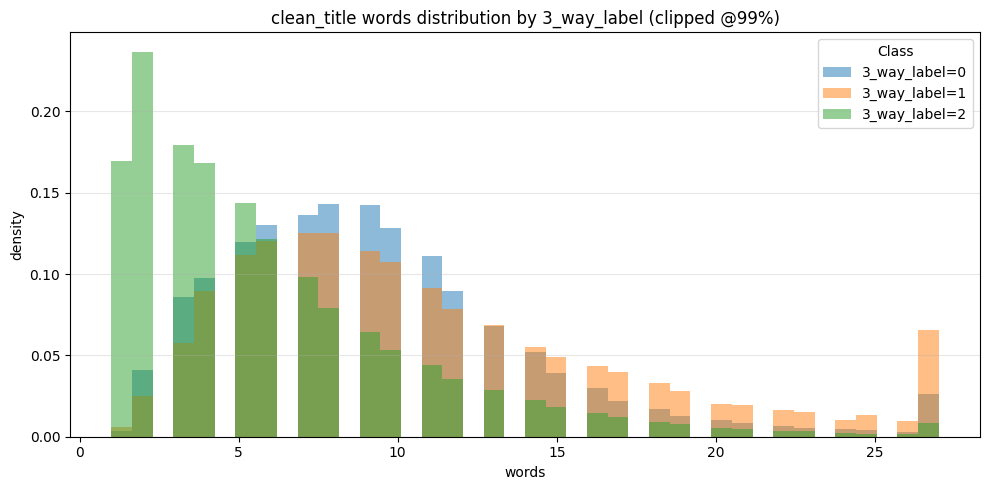


Top 15 tokens in clean_title by 3_way_label:

Class 0:
  a               12740
  the             12345
  in              8992
  this            8481
  of              7217
  to              7194
  on              4810
  my              4807
  and             3707
  for             3623
  with            3329
  at              2738
  i               2481
  is              2417
  from            2186


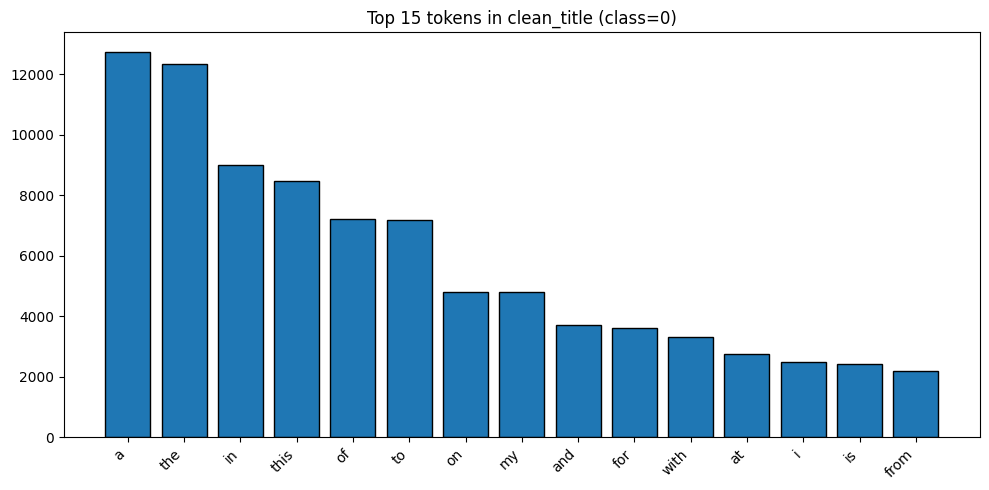


Class 1:
  the             1679
  of              822
  poster          657
  a               463
  to              443
  in              433
  and             404
  for             348
  by              326
  war             250
  s               243
  is              232
  from            219
  you             185
  us              157


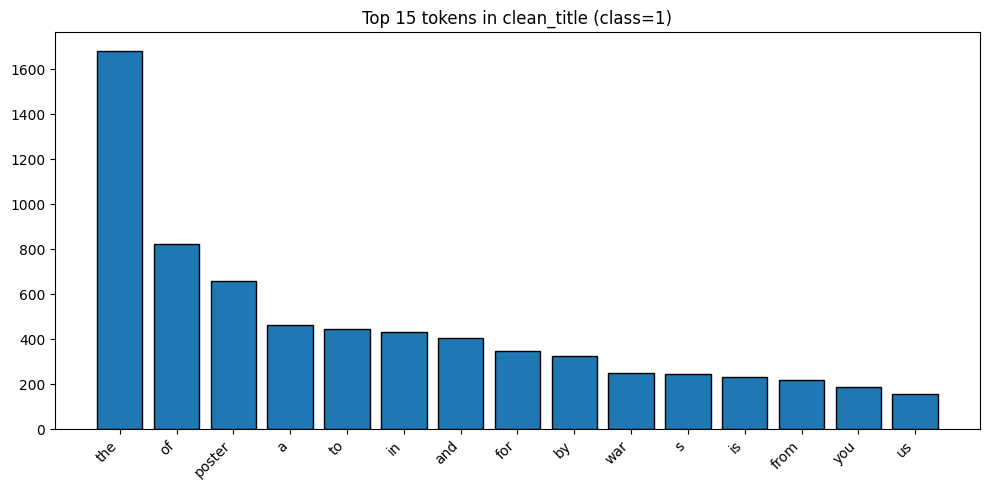


Class 2:
  the             14942
  a               8970
  of              7165
  to              6369
  in              5040
  this            4630
  i               4107
  is              3231
  my              3137
  and             2988
  on              2889
  you             2801
  for             2484
  it              2126
  with            1949


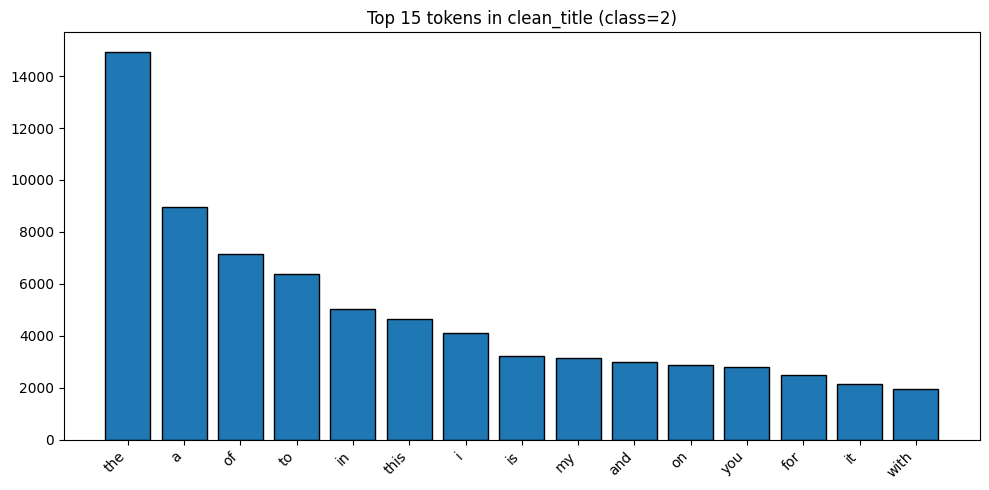


=== clean_title analysis by 6_way_label ===
             n_chars_mean  n_chars_med  n_words_mean  n_words_med       n
6_way_label                                                              
0                   53.57         49.0          9.45          9.0  222081
1                   45.19         34.0          7.60          6.0   33481
2                   40.59         35.0          7.23          6.0  107221
3                   77.24         73.0         14.62         14.0   11784
4                   21.12         17.0          3.95          3.0  167857
5                   66.26         60.0         11.23         10.0   21576


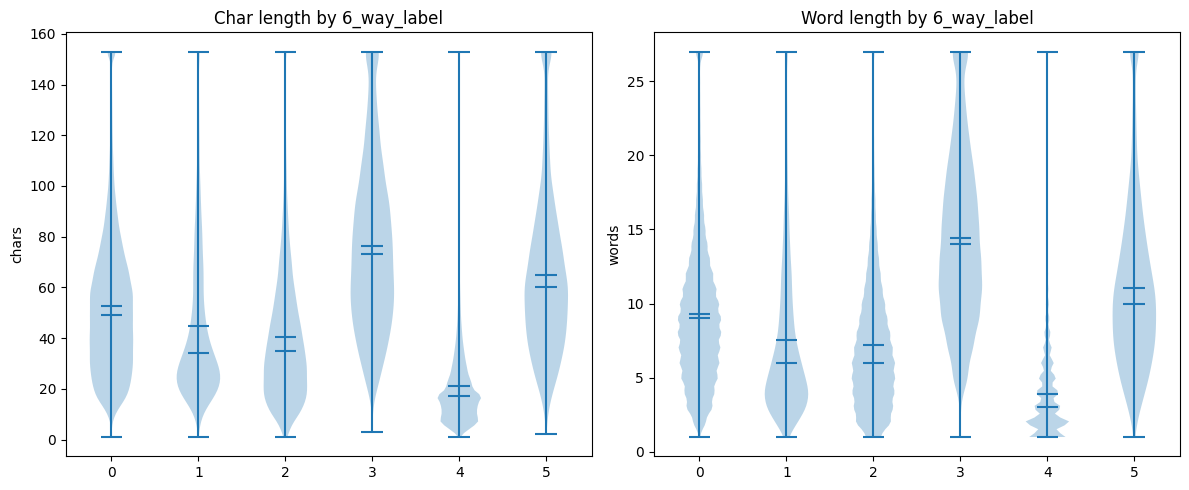

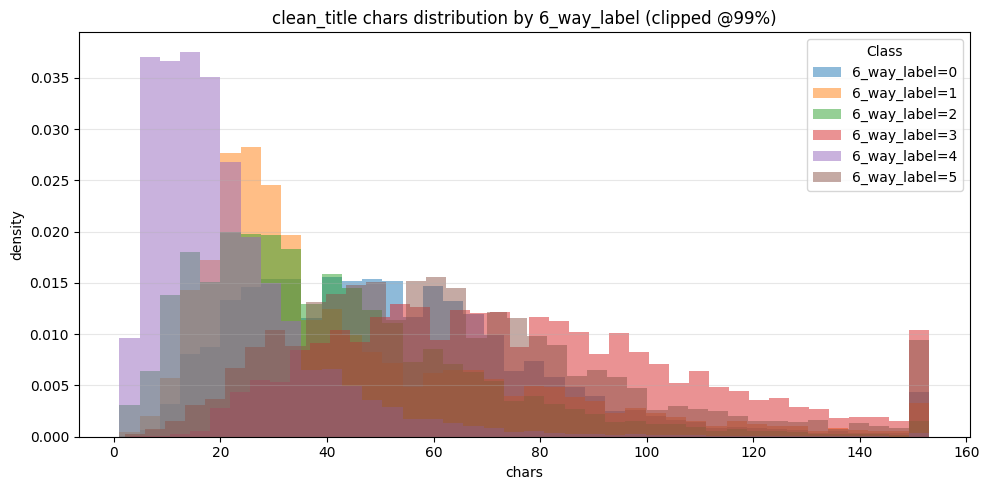

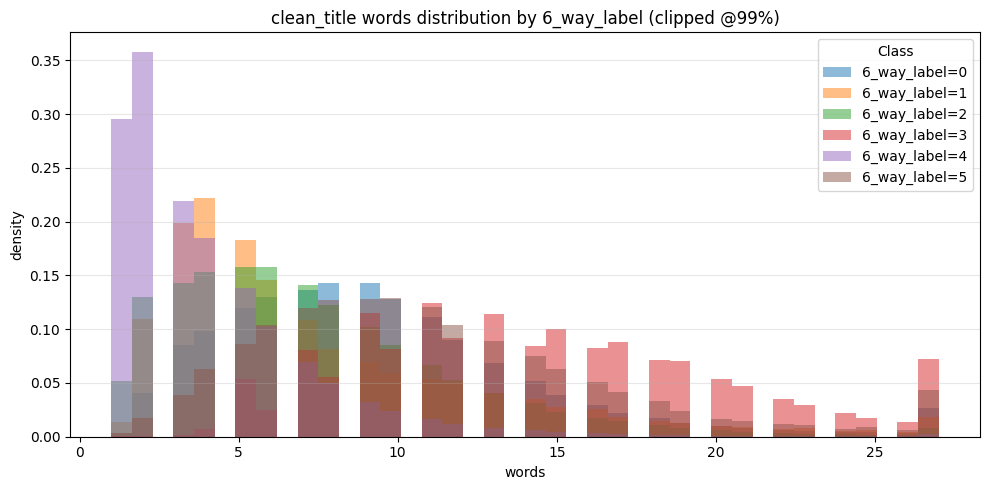


Top 15 tokens in clean_title by 6_way_label:

Class 0:
  a               12740
  the             12345
  in              8992
  this            8481
  of              7217
  to              7194
  on              4810
  my              4807
  and             3707
  for             3623
  with            3329
  at              2738
  i               2481
  is              2417
  from            2186


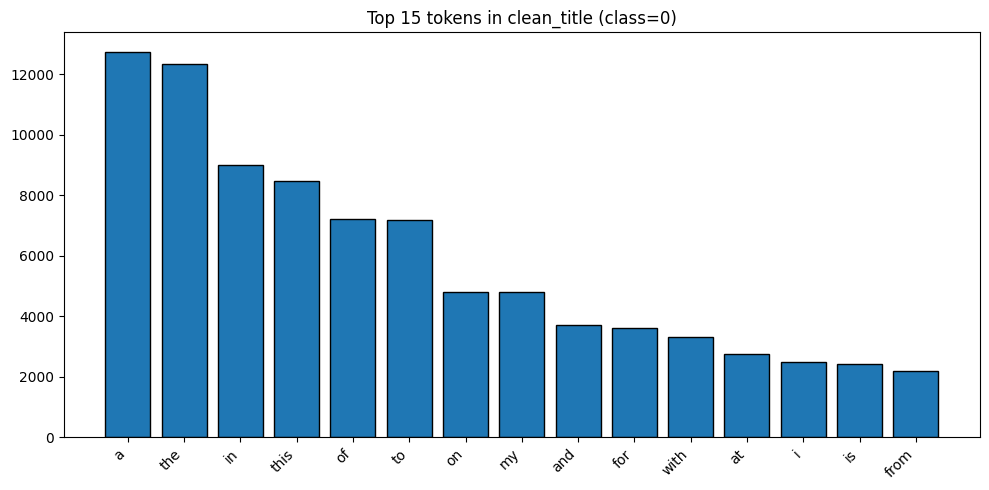


Class 1:
  the             1710
  to              1085
  of              929
  a               556
  in              537
  for             406
  and             371
  on              289
  is              256
  with            243
  you             233
  i               230
  this            221
  by              205
  from            187


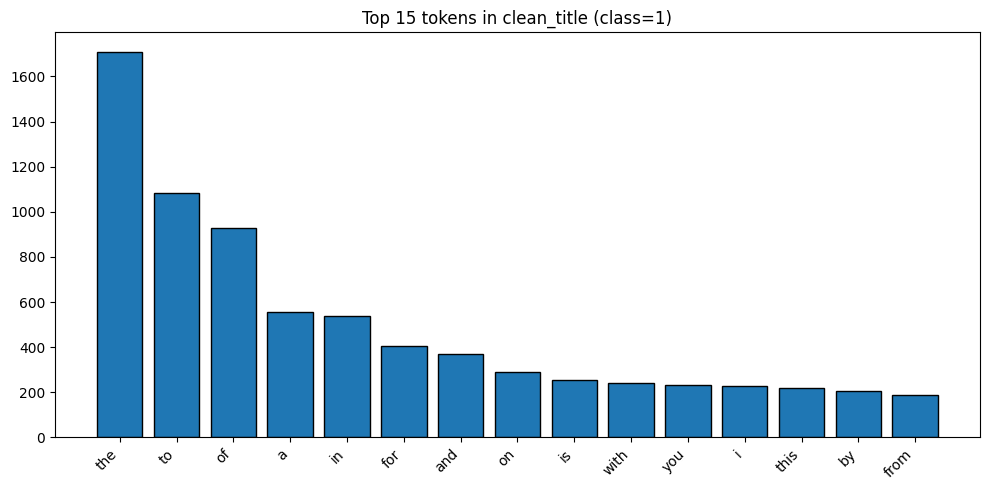


Class 2:
  the             6430
  a               4292
  of              3644
  in              2432
  this            2428
  to              2271
  my              1778
  on              1481
  is              1271
  i               1107
  and             1053
  at              993
  happy           920
  his             904
  for             770


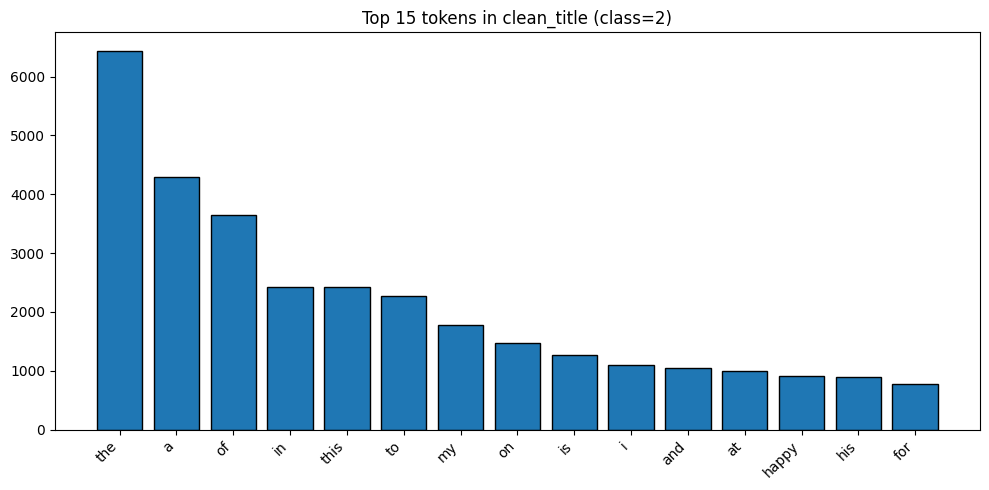


Class 3:
  the             1600
  a               1115
  to              884
  of              833
  in              658
  and             588
  i               578
  my              457
  is              387
  for             355
  on              347
  this            336
  with            274
  it              237
  you             214


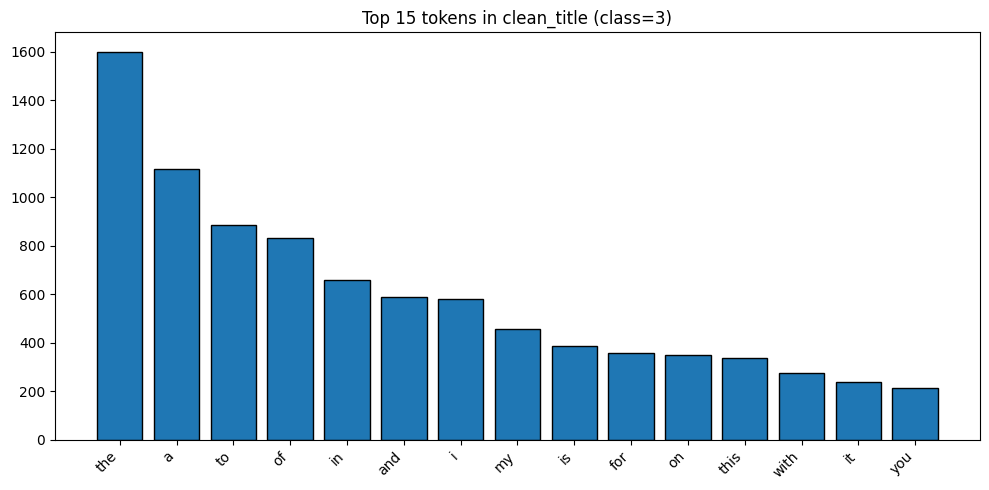


Class 4:
  the             4617
  a               2656
  i               2167
  to              1771
  you             1608
  of              1574
  other           1446
  this            1417
  discussions     1399
  cutouts         1184
  in              1177
  it              1133
  is              1083
  for             831
  and             803


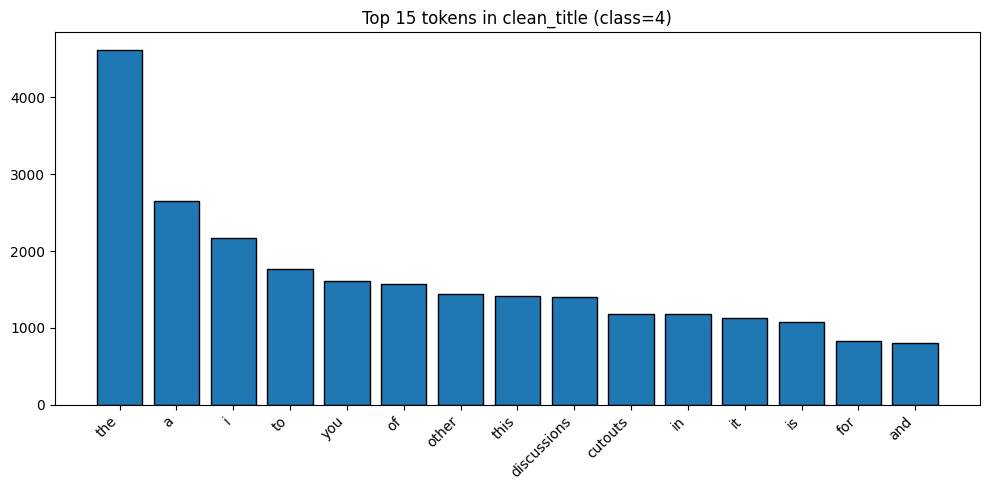


Class 5:
  the             2264
  of              1007
  a               814
  to              801
  in              669
  poster          657
  and             577
  for             470
  is              466
  you             398
  by              351
  this            320
  from            284
  war             257
  on              253


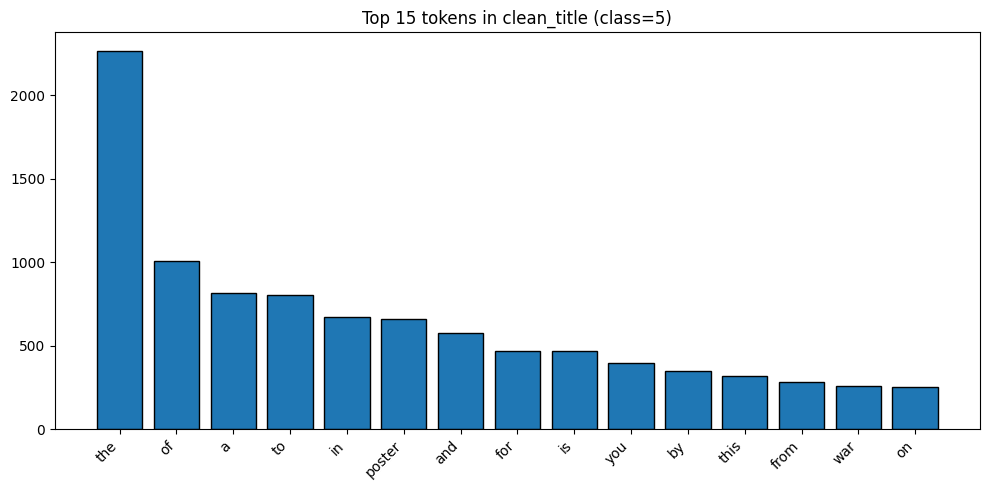

In [35]:
############################### Run on TRAIN
analyze_clean_title_by_label(
    train_df,
    text_col="clean_title",
    label_cols=("2_way_label","3_way_label","6_way_label"),
    top_n=15, clip_q=0.99, sample_n=100_000
)

### Image_url + Domain analysis

In [41]:
############################### image_url + domain analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def analyze_image_sources(
    df: pd.DataFrame,
    label_cols=("2_way_label","3_way_label","6_way_label"),
    domain_col="domain",
    url_col="image_url",
    top_n=10
):
    if domain_col not in df.columns or url_col not in df.columns:
        print(f"Columns '{domain_col}' or '{url_col}' not found.")
        return

    df = df.copy()
    df["_has_url"] = df[url_col].astype(str).str.strip() != ""

    for label_col in label_cols:
        if label_col not in df.columns:
            continue

        print(f"\n=== image_url/domain analysis by {label_col} ===")

        # ---- Availability
        avail = df.groupby(label_col)["_has_url"].agg(["sum","count"])
        avail["pct_has_url"] = (avail["sum"] / avail["count"] * 100).round(2)
        print("\n-- URL availability by class --")
        print(avail)

        # ---- Domain distribution
        df_valid = df[df["_has_url"]].copy()
        if df_valid.empty:
            print("No valid URLs for analysis.")
            continue

        ctab = pd.crosstab(df_valid[domain_col], df_valid[label_col])
        top_domains = ctab.sum(axis=1).sort_values(ascending=False).head(top_n).index
        ctab_top = ctab.loc[top_domains]

        # counts and fractions
        print(f"\n-- Top {top_n} domains by class (counts) --")
        print(ctab_top)

        frac = ctab_top.div(ctab_top.sum(axis=1), axis=0)

        ax = frac.plot(kind="bar", figsize=(12,6))
        ax.set_title(f"Top {top_n} domains by {label_col} (fractions within domain)")
        ax.set_xlabel("Domain"); ax.set_ylabel("Fraction of class usage")
        plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

        # ---- Domain diversity (unique count + entropy)
        diversity = df_valid.groupby(label_col)[domain_col].nunique()
        entropy = df_valid.groupby(label_col)[domain_col].apply(
            lambda x: -np.sum((x.value_counts(normalize=True) * np.log2(x.value_counts(normalize=True) + 1e-9)))
        )

        print("\n-- Domain diversity metrics --")
        metrics = pd.DataFrame({"unique_domains": diversity, "entropy": entropy.round(3)})
        print(metrics)

        # ---- Plot domain diversity
        fig, ax = plt.subplots(1,2,figsize=(12,5))
        diversity.plot(kind="bar", ax=ax[0], color="skyblue", edgecolor="black")
        ax[0].set_title(f"Unique domains per class ({label_col})"); ax[0].set_ylabel("Count")
        entropy.plot(kind="bar", ax=ax[1], color="salmon", edgecolor="black")
        ax[1].set_title(f"Domain entropy per class ({label_col})"); ax[1].set_ylabel("Entropy (bits)")
        plt.tight_layout(); plt.show()

    df.drop(columns=["_has_url"], inplace=True, errors="ignore")


=== image_url/domain analysis by 2_way_label ===

-- URL availability by class --
                sum   count  pct_has_url
2_way_label                             
0            341919  341919        100.0
1            222081  222081        100.0

-- Top 10 domains by class (counts) --
2_way_label              0      1
domain                           
i.redd.it            83976  92284
i.imgur.com          35627  39155
imgur.com            21114   8542
i.reddituploads.com   2294   1703
theonion.com          3714      0
archive.is            3193      5
clickhole.com         2507      0
reuters.com             21   2261
web.archive.org       2271      6
theguardian.com         75   2201


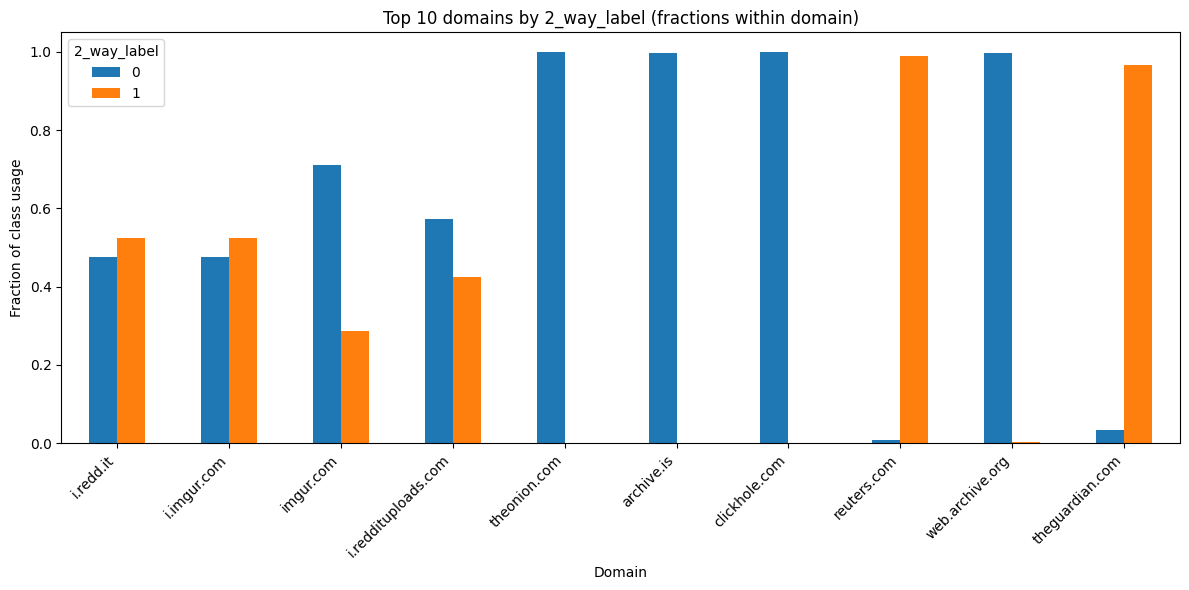


-- Domain diversity metrics --
             unique_domains  entropy
2_way_label                         
0                      3425    3.083
1                      8495    5.246


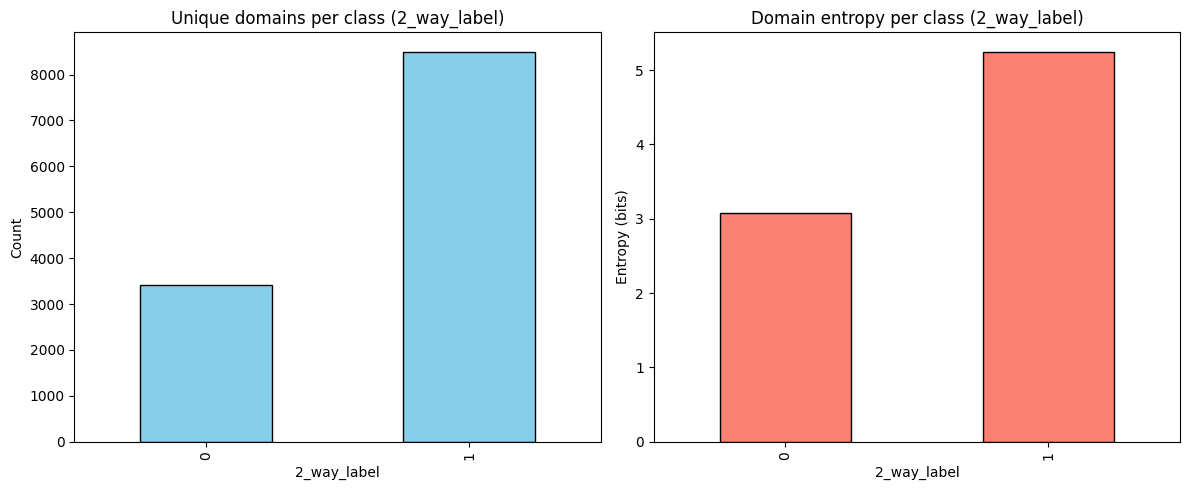


=== image_url/domain analysis by 3_way_label ===

-- URL availability by class --
                sum   count  pct_has_url
3_way_label                             
0            222081  222081        100.0
1             13848   13848        100.0
2            328071  328071        100.0

-- Top 10 domains by class (counts) --
3_way_label              0     1      2
domain                                 
i.redd.it            92284  5383  78593
i.imgur.com          39155  4069  31558
imgur.com             8542  1882  19232
i.reddituploads.com   1703    38   2256
theonion.com             0     0   3714
archive.is               5     0   3193
clickhole.com            0     0   2507
reuters.com           2261     0     21
web.archive.org          6     1   2270
theguardian.com       2201     3     72


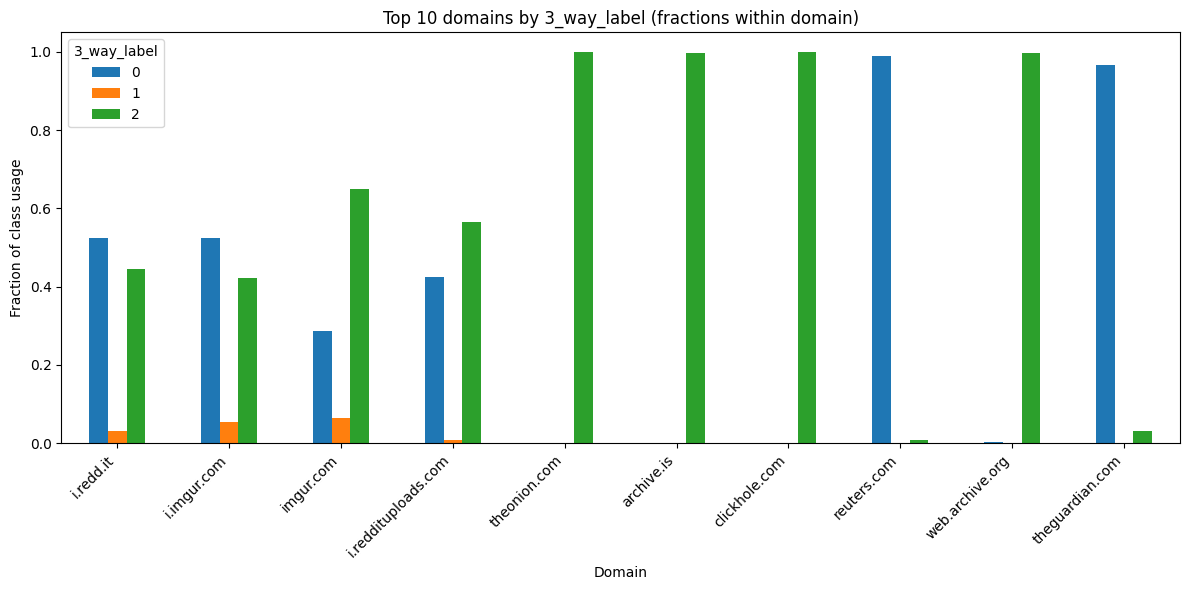


-- Domain diversity metrics --
             unique_domains  entropy
3_way_label                         
0                      8495    5.246
1                       779    3.133
2                      2807    3.018


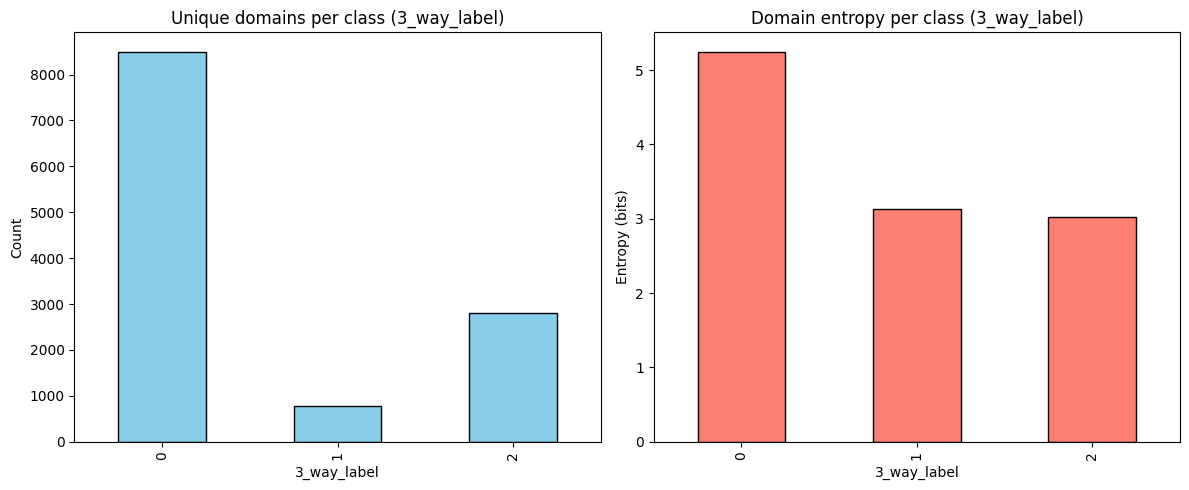


=== image_url/domain analysis by 6_way_label ===

-- URL availability by class --
                sum   count  pct_has_url
6_way_label                             
0            222081  222081        100.0
1             33481   33481        100.0
2            107221  107221        100.0
3             11784   11784        100.0
4            167857  167857        100.0
5             21576   21576        100.0

-- Top 10 domains by class (counts) --
6_way_label              0      1      2     3     5
domain                                              
i.redd.it            92284  16077  59973  2434  5492
i.imgur.com          39155   3808  25000  2718  4101
imgur.com             8542   1624  15724  1849  1917
i.reddituploads.com   1703    193   1782   268    51
theonion.com             0   3714      0     0     0
archive.is               5      0      0    24  3169
clickhole.com            0   2507      0     0     0
reuters.com           2261      0      0    21     0
web.archive.org    

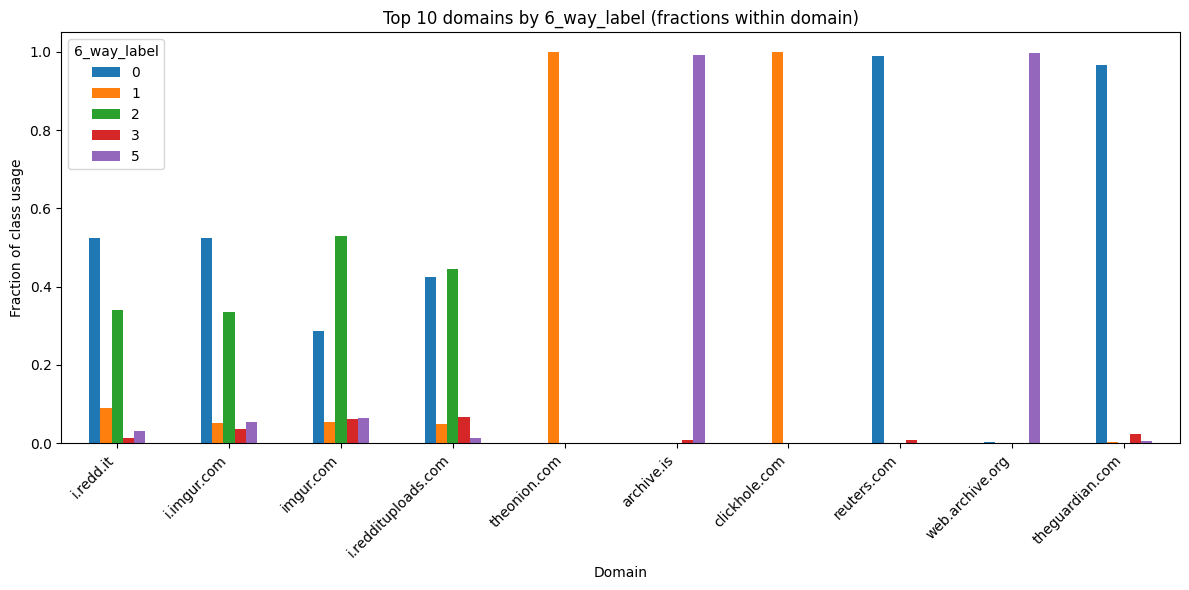


-- Domain diversity metrics --
             unique_domains  entropy
6_way_label                         
0                      8495    5.246
1                       781    3.321
2                       852    1.918
3                      1135    4.856
4                         0   -0.000
5                      1201    4.061


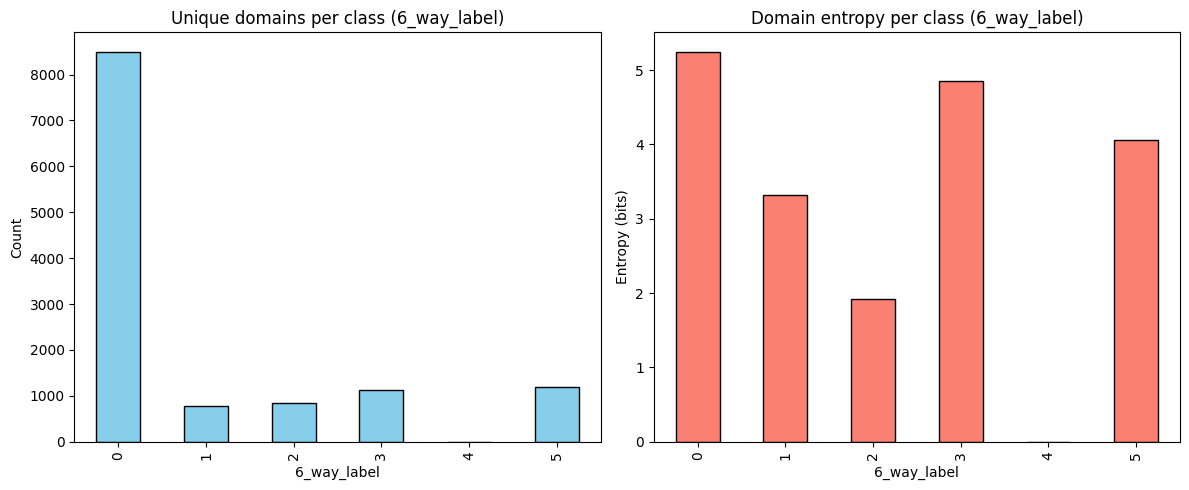

In [42]:
############################### Run on TRAIN
analyze_image_sources(
    train_df,
    label_cols=("2_way_label","3_way_label","6_way_label"),
    domain_col="domain",
    url_col="image_url",
    top_n=10
)

### Engagement Analysis

In [45]:
############################### engagement analysis
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_engagement_better(
    df: pd.DataFrame,
    label_cols=("2_way_label","3_way_label","6_way_label"),
    cols=("num_comments","score","upvote_ratio")
):
    for label_col in label_cols:
        if label_col not in df.columns:
            continue

        print(f"\n=== Engagement metrics (improved) by {label_col} ===")

        # ---- Log-scale plots for num_comments & score
        for metric in ["num_comments","score"]:
            if metric not in df.columns: 
                continue

            vals = df[[label_col, metric]].dropna().copy()
            vals[metric] = np.where(vals[metric] > 0, vals[metric], np.nan)  # drop nonpositive for log

            plt.figure(figsize=(10,5))
            for lab, g in vals.groupby(label_col):
                plt.hist(np.log1p(g[metric]), bins=40, density=True, alpha=0.5, label=f"{label_col}={lab}")
            plt.title(f"log(1+{metric}) distribution by {label_col}")
            plt.xlabel(f"log(1+{metric})"); plt.ylabel("density")
            plt.legend(title="Class"); plt.grid(axis="y", alpha=0.3)
            plt.tight_layout(); plt.show()

        # ---- Upvote ratio per class (boxplot, clearer than histogram)
        if "upvote_ratio" in df.columns:
            plt.figure(figsize=(8,5))
            sns.boxplot(x=label_col, y="upvote_ratio", data=df, showfliers=False)
            plt.title(f"Upvote ratio distribution by {label_col}")
            plt.xlabel(label_col); plt.ylabel("upvote_ratio")
            plt.tight_layout(); plt.show()

        # ---- Correlations between engagement metrics, per class
        sub = df[list(cols) + [label_col]].dropna()
        classes = sorted(sub[label_col].unique())
        for lab in classes:
            g = sub[sub[label_col]==lab][list(cols)]
            corr = g.corr()
            print(f"\nCorrelation matrix for {label_col}={lab}:")
            print(corr.round(2))

            plt.figure(figsize=(4,3))
            sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="coolwarm", cbar=False)
            plt.title(f"Correlations ({label_col}={lab})")
            plt.tight_layout(); plt.show()


=== Engagement metrics (improved) by 2_way_label ===


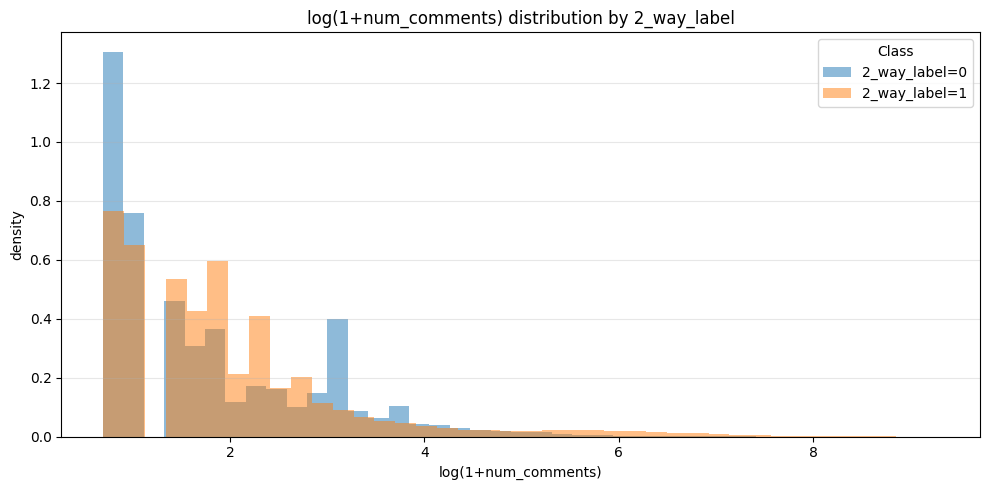

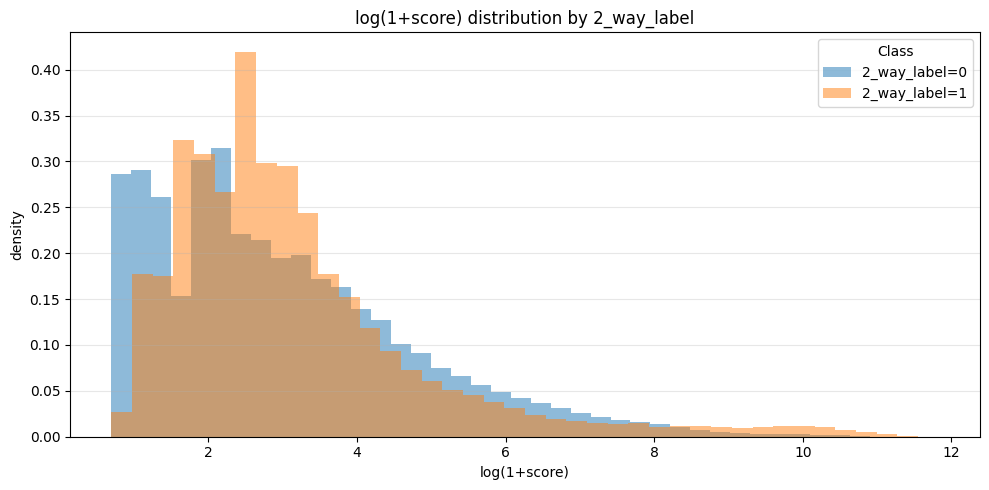

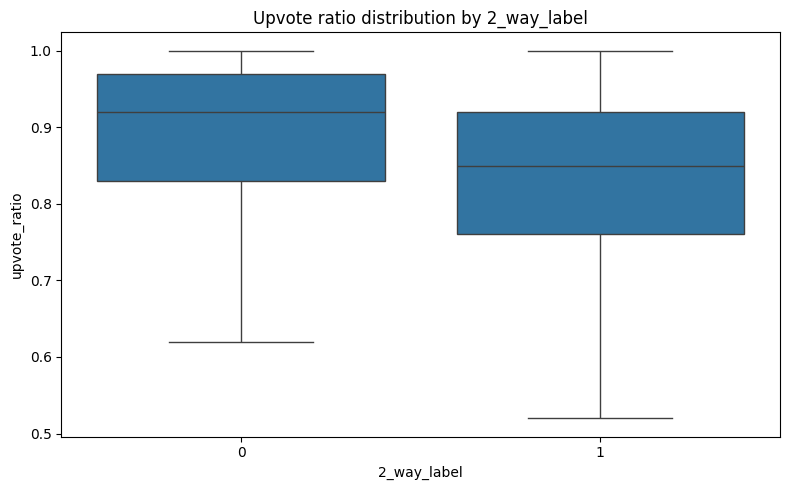


Correlation matrix for 2_way_label=0:
              num_comments  score  upvote_ratio
num_comments          1.00   0.55          0.05
score                 0.55   1.00          0.07
upvote_ratio          0.05   0.07          1.00


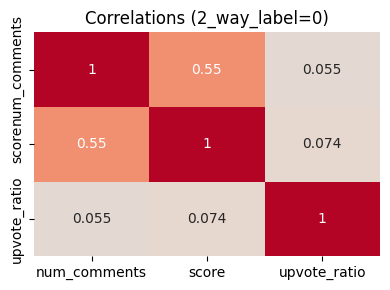


Correlation matrix for 2_way_label=1:
              num_comments  score  upvote_ratio
num_comments          1.00   0.70          0.08
score                 0.70   1.00          0.11
upvote_ratio          0.08   0.11          1.00


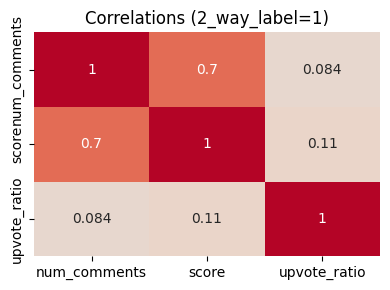


=== Engagement metrics (improved) by 3_way_label ===


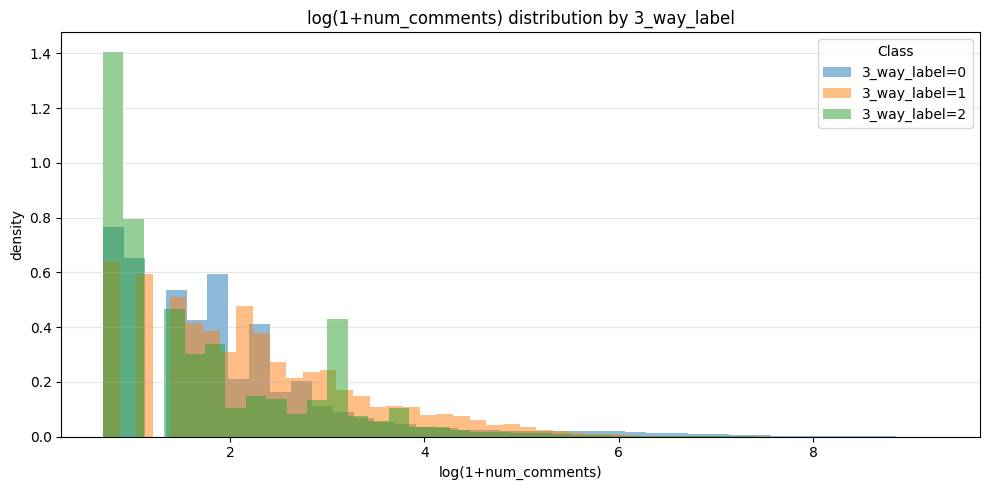

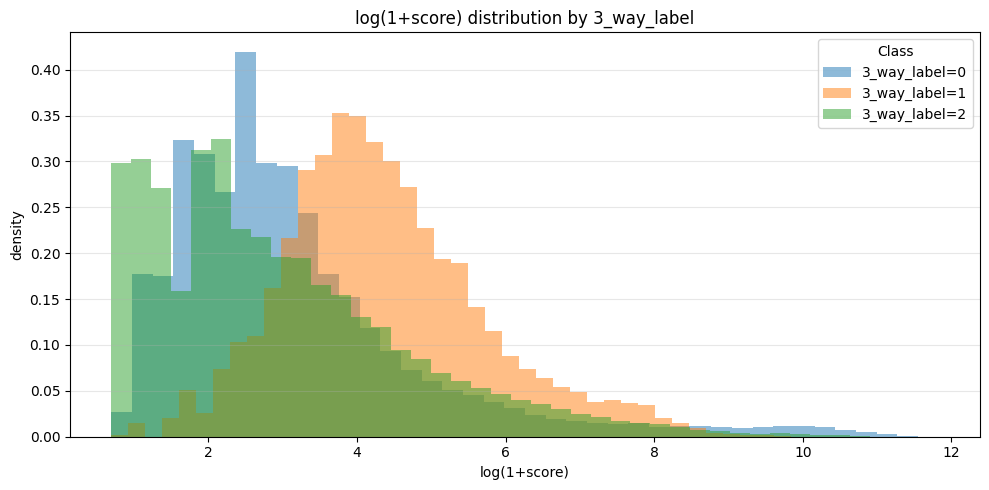

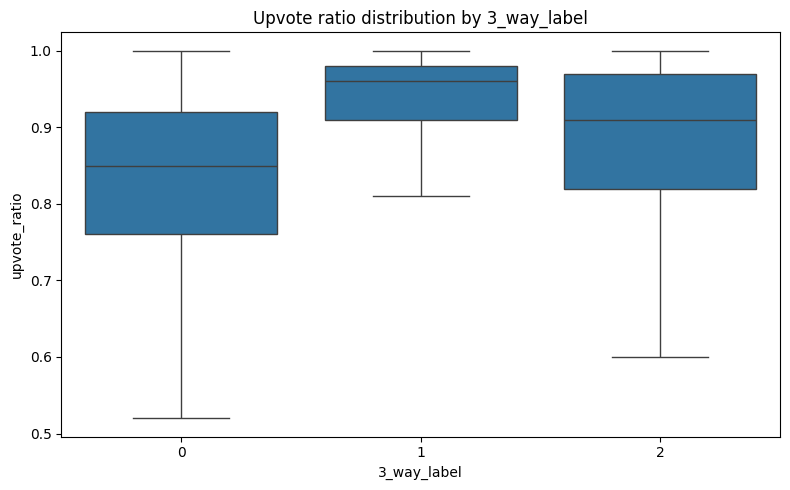


Correlation matrix for 3_way_label=0:
              num_comments  score  upvote_ratio
num_comments          1.00   0.70          0.08
score                 0.70   1.00          0.11
upvote_ratio          0.08   0.11          1.00


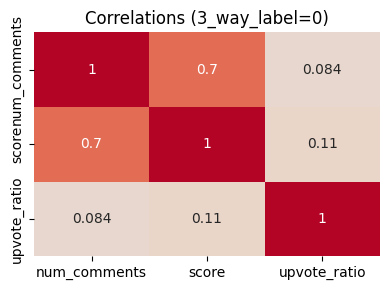


Correlation matrix for 3_way_label=1:
              num_comments  score  upvote_ratio
num_comments          1.00   0.77          0.08
score                 0.77   1.00          0.13
upvote_ratio          0.08   0.13          1.00


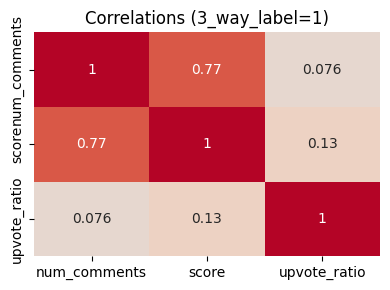


Correlation matrix for 3_way_label=2:
              num_comments  score  upvote_ratio
num_comments          1.00   0.56          0.05
score                 0.56   1.00          0.08
upvote_ratio          0.05   0.08          1.00


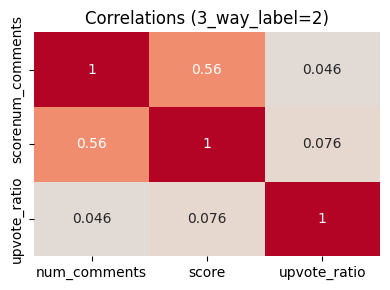


=== Engagement metrics (improved) by 6_way_label ===


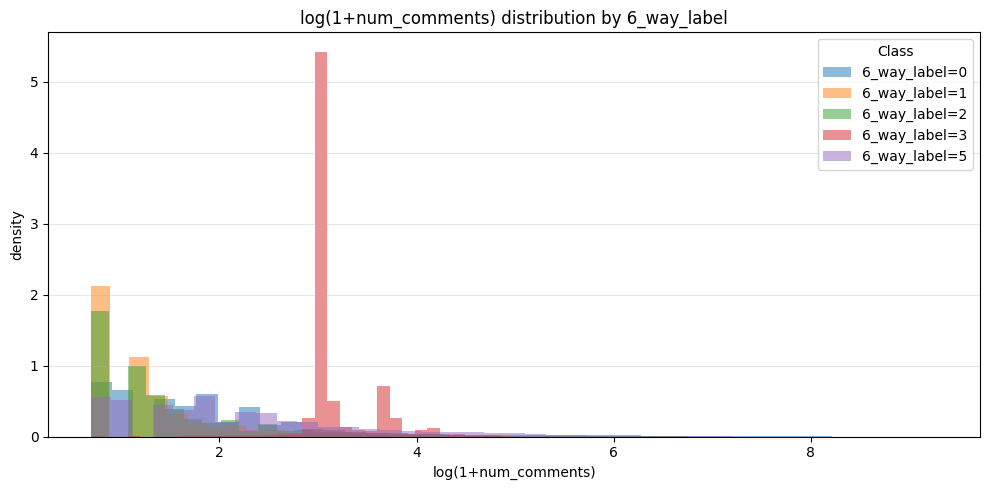

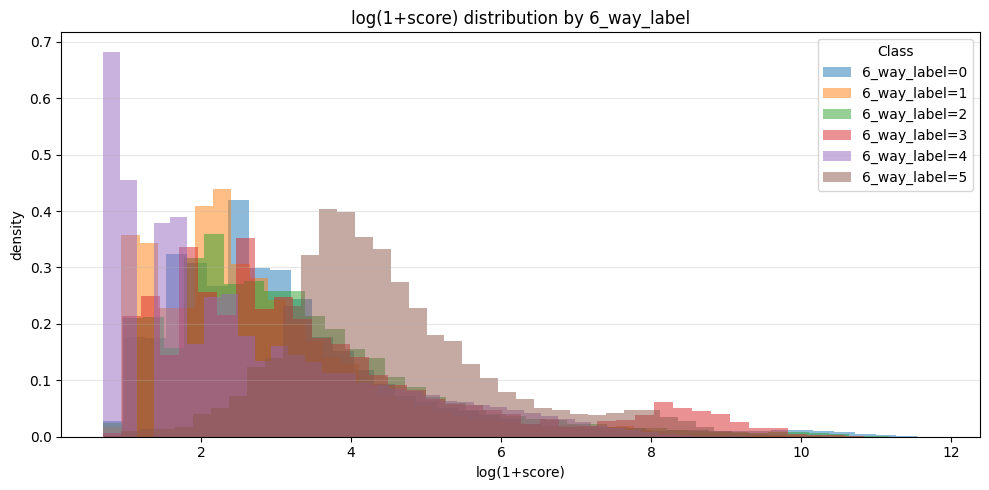

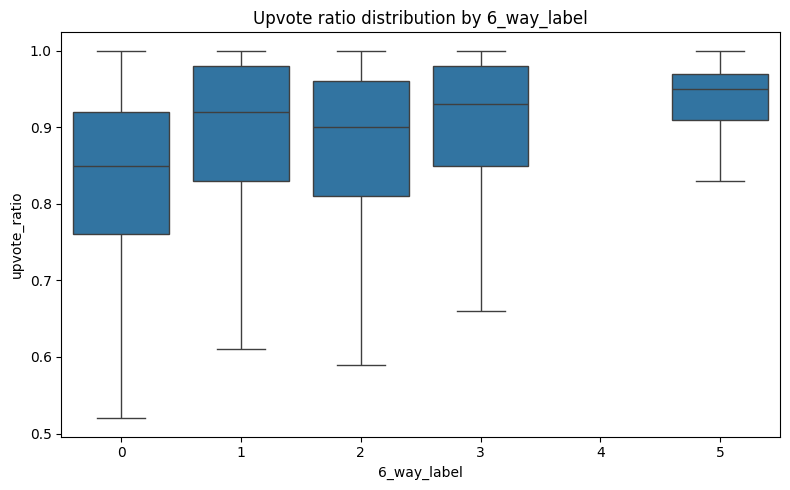


Correlation matrix for 6_way_label=0:
              num_comments  score  upvote_ratio
num_comments          1.00   0.70          0.08
score                 0.70   1.00          0.11
upvote_ratio          0.08   0.11          1.00


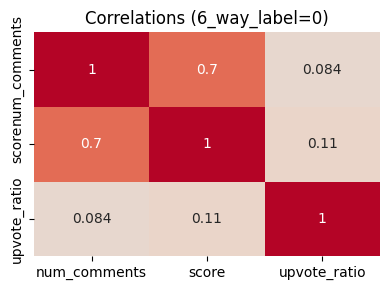


Correlation matrix for 6_way_label=1:
              num_comments  score  upvote_ratio
num_comments          1.00   0.43          0.02
score                 0.43   1.00          0.09
upvote_ratio          0.02   0.09          1.00


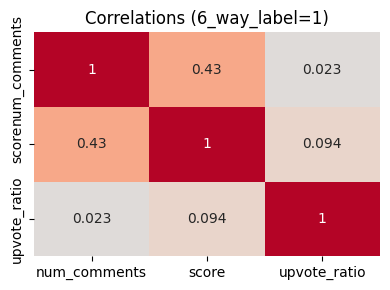


Correlation matrix for 6_way_label=2:
              num_comments  score  upvote_ratio
num_comments          1.00   0.71          0.05
score                 0.71   1.00          0.08
upvote_ratio          0.05   0.08          1.00


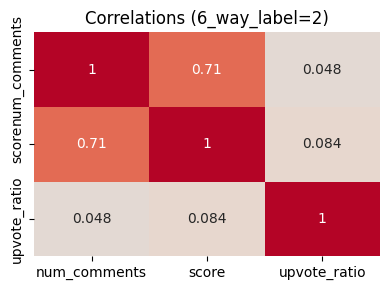


Correlation matrix for 6_way_label=3:
              num_comments  score  upvote_ratio
num_comments          1.00   0.22          0.04
score                 0.22   1.00          0.04
upvote_ratio          0.04   0.04          1.00


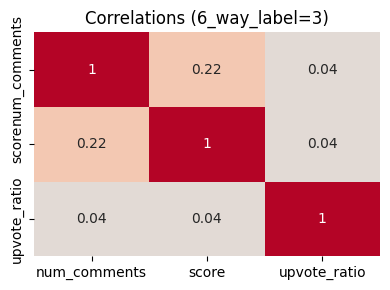


Correlation matrix for 6_way_label=5:
              num_comments  score  upvote_ratio
num_comments          1.00   0.63          0.03
score                 0.63   1.00          0.09
upvote_ratio          0.03   0.09          1.00


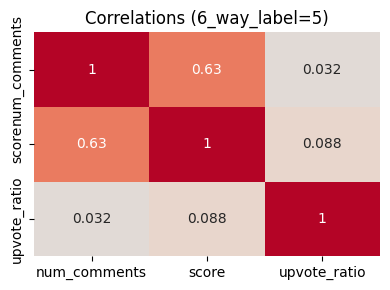

In [46]:
############################### Run on TRAIN
analyze_engagement_better(
    train_df,
    label_cols=("2_way_label","3_way_label","6_way_label"),
    cols=("num_comments","score","upvote_ratio")
)

# Image Properties

### Size, Brightness, Complexity

In [13]:
############################### helpers
def _safe_get(url, timeout=10):
    try:
        with request.urlopen(url, timeout=timeout) as r:
            b = r.read()
            if b and len(b) >= 100:  # skip empty/tiny
                return b
    except:
        pass
    return None

def _probe(b):
    try:
        im = Image.open(io.BytesIO(b)).convert("RGB")
        w, h = im.size
        arr = np.asarray(im, dtype=np.uint8)
        gray = (0.299*arr[...,0] + 0.587*arr[...,1] + 0.114*arr[...,2]).astype(np.float32)
        brightness = float(gray.mean())
        gx = np.abs(np.diff(gray, axis=1)).mean()
        gy = np.abs(np.diff(gray, axis=0)).mean()
        complexity = float((gx + gy) / 2.0)
        mpix = (w*h) / 1e6
        return dict(mpix=mpix, brightness=brightness, complexity=complexity)
    except:
        return None

############################### main (one label at a time)
def analyze_images_by_label_simple(train_df, label_col="2_way_label",
                                   sample_n=300, timeout=10, clip_q=0.99):
    ############################### pick deterministic top-N with valid URLs
    has_img = (train_df["hasImage"]) & (train_df["image_url"].astype(str).str.strip() != "")
    rows = train_df.loc[has_img, ["id", "image_url", label_col]].head(sample_n)

    ############################### download + probe
    recs = []
    for _, r in rows.iterrows():
        b = _safe_get(r["image_url"], timeout=timeout)
        if b is None: 
            continue
        p = _probe(b)
        if p is None: 
            continue
        p[label_col] = r[label_col]
        recs.append(p)

    if not recs:
        print("No images could be analyzed.")
        return pd.DataFrame()

    dfm = pd.DataFrame(recs)

    ############################### clip outliers for plotting only
    plot_df = dfm.copy()
    for col in ["mpix","brightness","complexity"]:
        q = plot_df[col].quantile(clip_q)
        plot_df[col] = np.minimum(plot_df[col], q)

    ############################### tiny summary (n, mean, median) per class
    summary = dfm.groupby(label_col)[["mpix","brightness","complexity"]].agg(
        n=("mpix","count"),
        mpix_mean=("mpix","mean"), mpix_med=("mpix","median"),
        bright_mean=("brightness","mean"), bright_med=("brightness","median"),
        comp_mean=("complexity","mean"), comp_med=("complexity","median"),
    ).round(2)
    print(f"\n=== Image properties by {label_col} (train, n up to {sample_n}) ===")
    print(summary)

    ############################### 3 boxplots (easy to compare)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

    # mpix
    data = [g["mpix"].values for _, g in plot_df.groupby(label_col)]
    labels = [str(l) for l in plot_df[label_col].unique()]
    axes[0].boxplot(data, showmeans=True)
    axes[0].set_title("Size (megapixels)")
    axes[0].set_xticks(range(1, len(labels)+1)); axes[0].set_xticklabels(labels)
    axes[0].grid(True, alpha=0.3)

    # brightness
    data = [g["brightness"].values for _, g in plot_df.groupby(label_col)]
    axes[1].boxplot(data, showmeans=True)
    axes[1].set_title("Brightness (0–255)")
    axes[1].set_xticks(range(1, len(labels)+1)); axes[1].set_xticklabels(labels)
    axes[1].grid(True, alpha=0.3)

    # complexity
    data = [g["complexity"].values for _, g in plot_df.groupby(label_col)]
    axes[2].boxplot(data, showmeans=True)
    axes[2].set_title("Complexity (avg |grad|)")
    axes[2].set_xticks(range(1, len(labels)+1)); axes[2].set_xticklabels(labels)
    axes[2].grid(True, alpha=0.3)

    fig.suptitle(f"Image properties by {label_col} (clipped @{int(clip_q*100)}%)",fontsize=12, y=1.05)
    plt.show()

    return dfm


=== Image properties by 2_way_label (train, n up to 500) ===
               n  mpix_mean  mpix_med  bright_mean  bright_med  comp_mean  \
2_way_label                                                                 
0            136        0.1      0.10       118.50      117.76       7.73   
1            197        0.1      0.08       110.07      110.05       7.19   

             comp_med  
2_way_label            
0                6.76  
1                6.58  


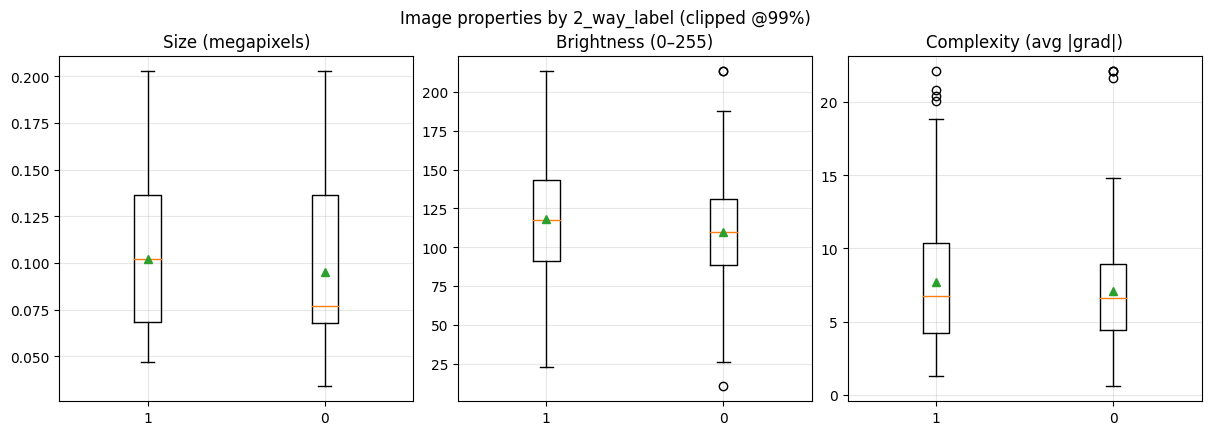


=== Image properties by 3_way_label (train, n up to 500) ===
               n  mpix_mean  mpix_med  bright_mean  bright_med  comp_mean  \
3_way_label                                                                 
0            197       0.10      0.08       110.07      110.05       7.19   
1             16       0.12      0.14       130.81      139.04       9.84   
2            120       0.10      0.10       116.86      114.25       7.45   

             comp_med  
3_way_label            
0                6.58  
1                8.86  
2                6.61  


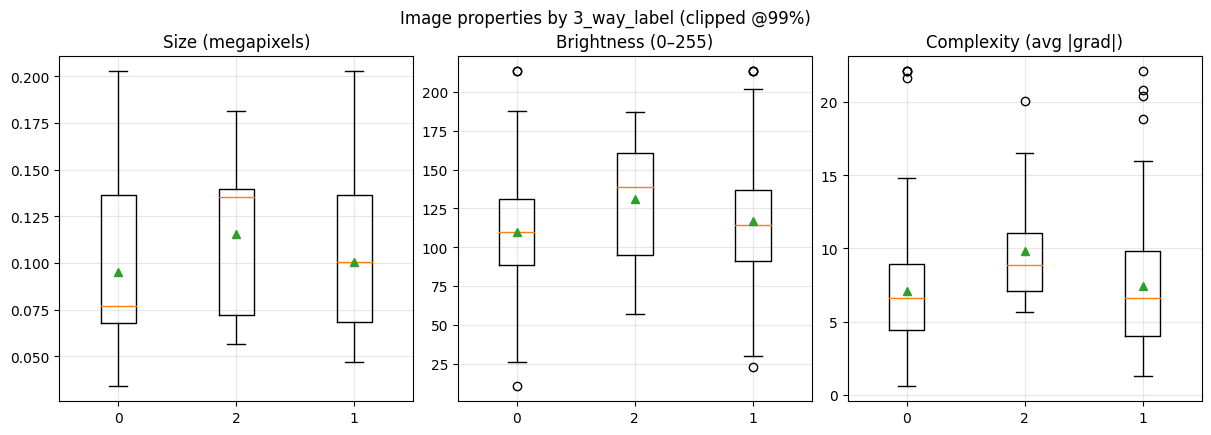


=== Image properties by 6_way_label (train, n up to 500) ===
               n  mpix_mean  mpix_med  bright_mean  bright_med  comp_mean  \
6_way_label                                                                 
0            197       0.10      0.08       110.07      110.05       7.19   
1             21       0.09      0.10       117.47      106.19       7.59   
2             86       0.10      0.10       118.25      115.98       7.31   
3              9       0.10      0.07       103.22       99.35       8.31   
5             20       0.11      0.10       127.55      133.42       9.44   

             comp_med  
6_way_label            
0                6.58  
1                5.93  
2                6.53  
3                7.41  
5                8.31  


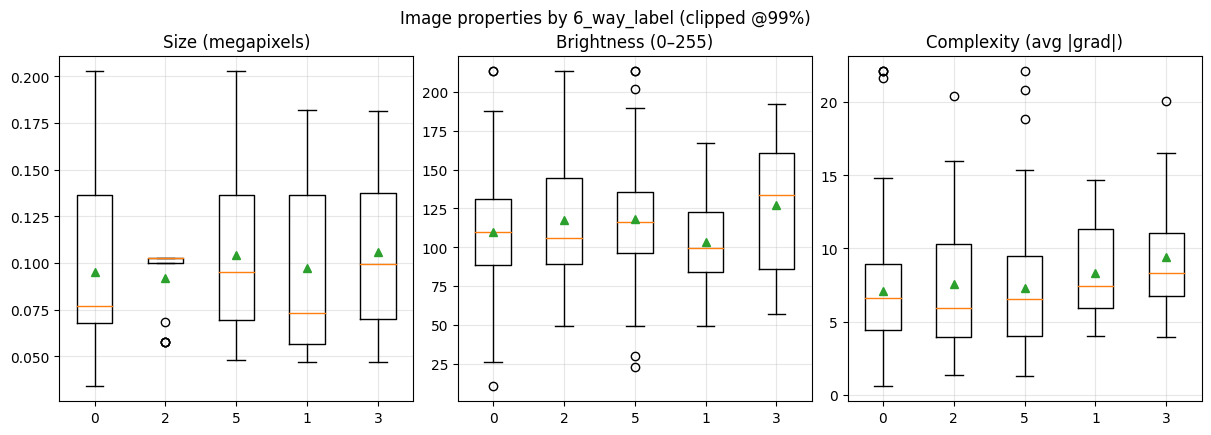

In [14]:
############################### 2-way (real vs fake)
img2 = analyze_images_by_label_simple(train_df, label_col="2_way_label", sample_n=500)

############################### 3-way
img3 = analyze_images_by_label_simple(train_df, label_col="3_way_label", sample_n=500)

############################### 6-way
img6 = analyze_images_by_label_simple(train_df, label_col="6_way_label", sample_n=500)

### Average image quality metrics


=== Average image quality metrics by 2_way_label ===
Explanation of metrics:
  • mpix: image resolution in megapixels (higher = larger image).
  • blur: variance of Laplacian proxy (higher = sharper, lower = blurrier).
  • complexity: average edge/gradient strength (higher = more noisy/detailed).

The table below shows mean, median, and std deviation of these metrics per class.

            mpix                 blur                 complexity             
            mean median   std    mean  median     std       mean median   std
2_way_label                                                                  
0            0.1   0.09  0.04  188.74  135.28  171.48       7.74   6.88  4.43
1            0.1   0.08  0.04  139.81  112.17  123.73       7.13   6.55  4.38


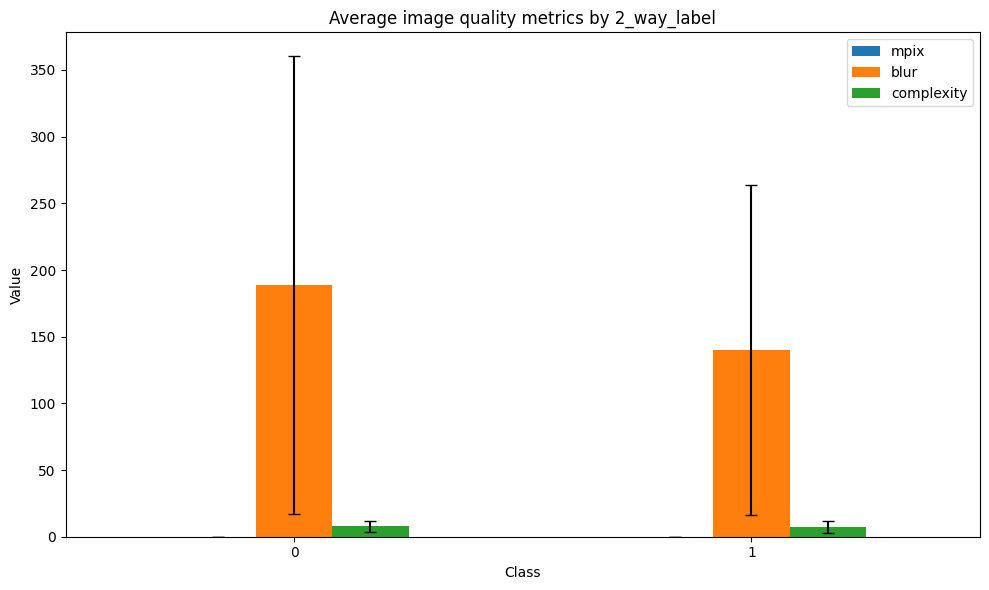

In [53]:
############################### Average image quality metrics (with explanation)
def analyze_image_quality_means(dfm, label_col="2_way_label"):
    if dfm.empty:
        print("No image features provided.")
        return

    metrics = ["mpix","blur","complexity"]
    summary = dfm.groupby(label_col)[metrics].agg(["mean","median","std"]).round(2)

    # explanation
    print(f"\n=== Average image quality metrics by {label_col} ===")
    print("Explanation of metrics:")
    print("  • mpix: image resolution in megapixels (higher = larger image).")
    print("  • blur: variance of Laplacian proxy (higher = sharper, lower = blurrier).")
    print("  • complexity: average edge/gradient strength (higher = more noisy/detailed).")
    print("\nThe table below shows mean, median, and std deviation of these metrics per class.\n")
    print(summary)

    # plot with error bars
    means = dfm.groupby(label_col)[metrics].mean()
    stds = dfm.groupby(label_col)[metrics].std()

    ax = means.plot(kind="bar", yerr=stds, figsize=(10,6), capsize=4)
    ax.set_title(f"Average image quality metrics by {label_col}")
    ax.set_ylabel("Value")
    ax.set_xlabel("Class")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return summary

############################### Run on extended features
quality_means = analyze_image_quality_means(img2_ext, label_col="2_way_label")

# Text + Image Analysis

### Display sample text–image pairs

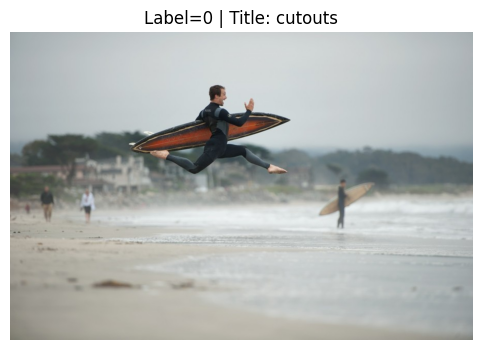

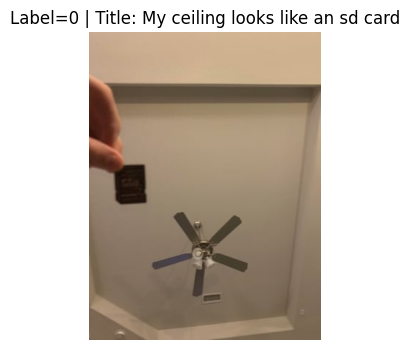

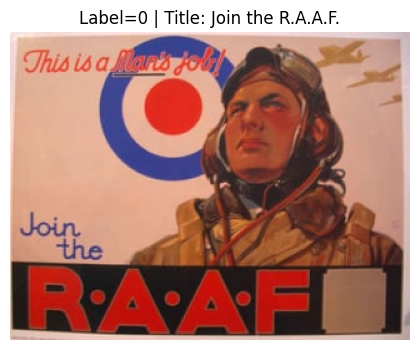

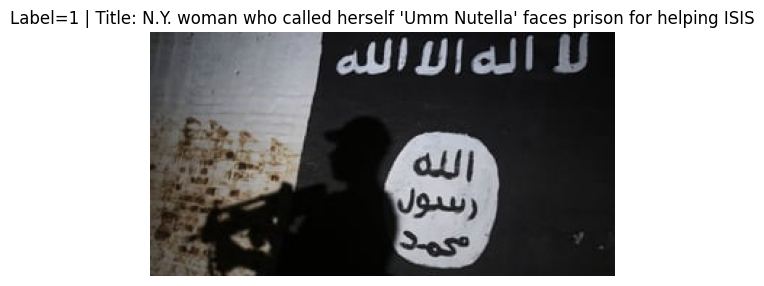

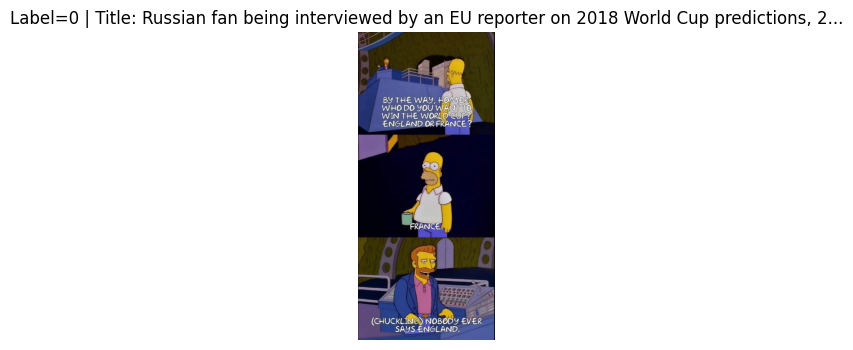

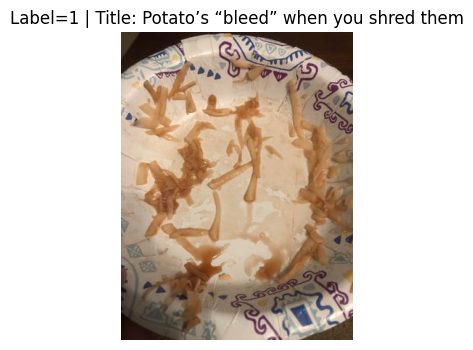

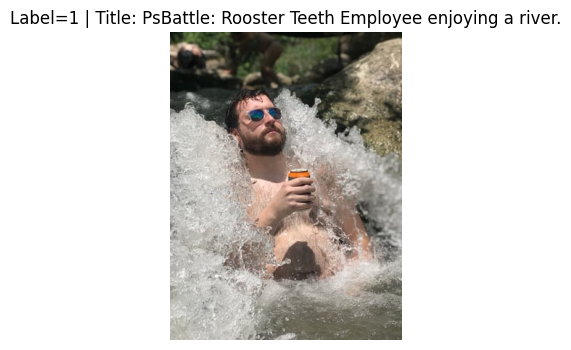

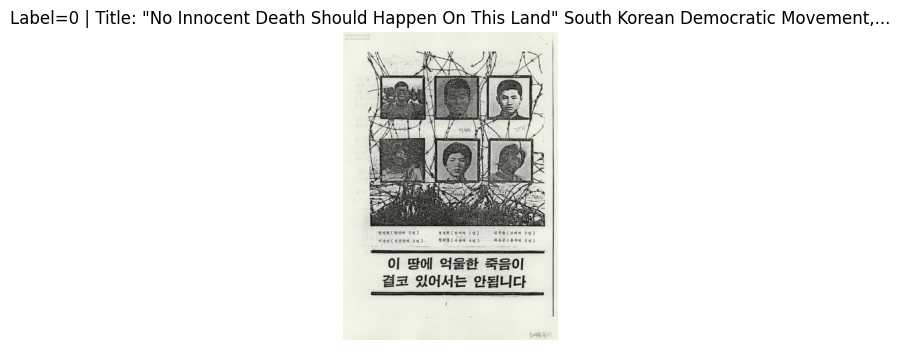

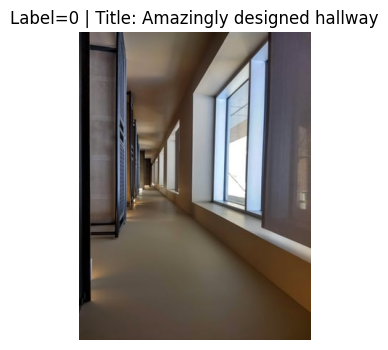

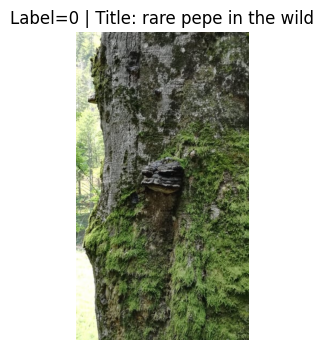

In [57]:
############################### Show sample text-image pairs (no saving)
def show_text_image_samples(df, label_col="2_way_label", sample_n=5, timeout=12):
    has_img = (df["hasImage"]) & (df["image_url"].astype(str).str.strip() != "")
    rows = df.loc[has_img, ["title","image_url",label_col]].sample(sample_n, random_state=42)

    for _, r in rows.iterrows():
        url = r["image_url"]
        try:
            data = request.urlopen(url, timeout=timeout).read()
            if not data or len(data) < 100:
                continue
            im = Image.open(io.BytesIO(data)).convert("RGB")
        except:
            continue

        plt.figure(figsize=(6,4))
        plt.imshow(im)
        plt.axis("off")
        plt.title(f"Label={r[label_col]} | Title: {r['title'][:80]}{'...' if len(r['title'])>80 else ''}")
        plt.show()

############################### Run on TRAIN
show_text_image_samples(train_df, label_col="2_way_label", sample_n=15)

## Downloading Images and Creating sub-datasets

In [32]:
def create_subcsv_and_download(df, base_dir, csv_name="train_subset.csv", img_folder="train_images", limit=10):
    # clean
    df = df.replace(np.nan, '', regex=True)
    df.fillna('', inplace=True)

    ############################### paths
    img_dir = os.path.join(base_dir, img_folder)
    os.makedirs(img_dir, exist_ok=True)

    picked = []
    count = 0

    ############################### progress bar setup
    if limit == -1:
        iterator = tqdm(df.iterrows(), total=len(df), desc="Downloading images", unit="row")
    else:
        iterator = df.iterrows()
        pbar = trange(limit, desc="Downloading images", unit="img")

    for _, row in iterator:
        if limit != -1 and count >= limit:
            break

        if row["hasImage"] == True and row["image_url"] not in ["", "nan"]:
            url = row["image_url"]
            final_path = os.path.join(img_dir, f"{row['id']}.jpg")
            tmp_path = final_path + ".tmp"

            try:
                data = request.urlopen(url, timeout=12).read()
                if not data or len(data) < 100:
                    continue

                with open(tmp_path, "wb") as f:
                    f.write(data)
                os.replace(tmp_path, final_path)

                picked.append(row)
                if limit != -1:
                    count += 1
                    pbar.update(1)

            except:
                if os.path.exists(tmp_path):
                    os.remove(tmp_path)
                continue

    if limit != -1:
        pbar.close()

    ############################### save CSV of successfully downloaded rows
    out_csv = os.path.join(base_dir, csv_name)
    pd.DataFrame(picked).to_csv(out_csv, index=False)
    print(f"\nCreated {out_csv} with {len(picked)} rows")
    print(f"Images saved in {img_dir}")

In [33]:
############################### Train Sub dataset
create_subcsv_and_download(
    df=train_df,
    base_dir=str(BASE_DATA_DIR),
    csv_name="train_subset.csv",
    img_folder="train_images",
    limit=1000
)

############################### Valid Sub dataset
create_subcsv_and_download(
    df=val_df,
    base_dir=str(BASE_DATA_DIR),
    csv_name="valid_subset.csv",
    img_folder="valid_images",
    limit=100
)

############################### Test Sub dataset
create_subcsv_and_download(
    df=test_df,
    base_dir=str(BASE_DATA_DIR),
    csv_name="test_subset.csv",
    img_folder="test_images",
    limit=100
)


Created ../../project_dataset/fakeddit_data/multimodal_only_samples/train_subset.csv with 1000 rows
Images saved in ../../project_dataset/fakeddit_data/multimodal_only_samples/train_images



Created ../../project_dataset/fakeddit_data/multimodal_only_samples/valid_subset.csv with 100 rows
Images saved in ../../project_dataset/fakeddit_data/multimodal_only_samples/valid_images



Created ../../project_dataset/fakeddit_data/multimodal_only_samples/test_subset.csv with 100 rows
Images saved in ../../project_dataset/fakeddit_data/multimodal_only_samples/test_images
